<a href="https://colab.research.google.com/github/eitellauria/Applied_Causal_Inference_Course/blob/main/bambi_retention_colab_with_RQ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Freshmen_Retention (using bambi)
(for Colab)
 8/20/2025

 Includes code  for interaction

CHeck:

- https://bambinos.github.io/bambi/notebooks/logistic_regression.html



In [ ]:
!pip install -q arviz>=0.12.0 formulae>=0.5.3 graphviz pandas>=1.0.0 pymc>=5.18.0
!pip install -q bambi
!pip install -q fancyimpute


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import arviz as az
import bambi as bmb
import pymc as pm

import seaborn as sns
import time
from datetime import datetime

from sklearn import preprocessing

from fancyimpute import KNN

import warnings
# Suppress specific warning
warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 666
az.style.use("arviz-darkgrid")

In [ ]:
#import psutil
#import multiprocessing

# Get total memory in bytes and convert to GB
#total_memory_gb = psutil.virtual_memory().total / (1024**3)

# Get the number of available CPU cores
#cpu_cores = multiprocessing.cpu_count()

#print(f"Total memory: {total_memory_gb:.2f} GB")
#print(f"Number of CPU cores: {cpu_cores}")

In [ ]:
#import jax
#import jax.numpy as jnp

#try:
    # Attempt a simple JAX operation on the GPU
#    key = jax.random.PRNGKey(0)
#    x = jnp.ones((1, 1))
#    y = jax.jit(lambda x: x @ x.T)(x)
#    # If the above operation succeeds on the GPU, print the device info
#    print("GPU is available. Device info:")
#    print(jax.devices())
#except RuntimeError as e:
    # If a runtime error occurs (likely due to no GPU being found), print an error message
#    print("GPU is not available. JAX is running on CPU.")
#    print(f"Error: {e}")

In [ ]:
bmb.inference_methods.names

{'pymc': {'mcmc': ['mcmc'], 'vi': ['vi']}, 'bayeux': {'mcmc': []}}

## Helper Functions

In [ ]:
def select_period(df, year_list):
    # Filter the DataFrame based on whether TERM_CODE_IR is in the year_list
    return df[df['TERM_CODE_IR'].isin(year_list)]

#---------------------------------------------------------------------------
# Function to process features
def process_features(df, missing_threshold=0.5):

    cols = ['TERM_CODE_IR', 'AGE', 'EFC', 'pellEligable',
            'pell_amount', 'studentOfColor', 'gender', 'isFirstGeneration',
            'distanceFromHome',
            'isHEOP',
            #'VisaType','OtherCitizenship', 'USPermRes',
            'USCitizen',
            'HSRankPercent',
            'ClassRank', 'ClassSize', 'HSGPA', 'HSMatriculationRate',
            'NumAPCourses', 'NumHonorsCourses', 'NumIBHCourses', 'NumIBSCourses',
            'applicantTypeCode',
            #'levelOfInterest',
            'WaitListYN', 'isMeritScholarship',
            'UnmetNeed', 'hasLoans', 'DepositDate',
            'initialHousingAssignment','initialHousingRelocationCount',
            'SchoolCode', 'MAJOR',
            'isDivisionI', 'isLSP', 'isHonorsProgram',
            #'isFFE', 'isFDE',
            'isCampusWorkStudy',
            #'GPA_EffectiveEndOfFall',
            'GPA_EffectiveEndOfAcademicYear',
            #'gradeFYS', 'isFullTimeFYS', 'isTakenInFallFYS','countTakenFYS',
            #'GradeCountFall', 'FailCountFall', 'WithdrawCountFall',
            #'GradeCountSpring', 'FailCountSpring', 'WithdrawCountSpring',
            'isAcademicProbation', 'conductCaseCount', 'isSelfDevelopment',
            'isCareerPlanning', 'tutoringClassCount',
            'isReferredForTutoring', 'isGreekLife',
            'percentCreditsFullTimeFall', 'isClubAthlete', 'ISDEANSLIST',
            'didNotReturnNextFallIR']

    # Select the columns
    df = df[cols].copy()

    # Drop columns with all missing values
    df = df.dropna(axis='columns', how="all")

    #Drop columns with SchoolCode="CT"
    df = df.query('SchoolCode!="CT"').copy()


    # Drop columns with all missing values
    df = df[df['gender'] != 'N'].copy()



    # Drop columns with missing value percentage above the threshold
    threshold_count = len(df) * missing_threshold
    df = df.dropna(thresh=threshold_count, axis=1)

    # Identify and drop columns that are constant
    constant_columns = [col for col in df.columns if df[col].nunique() == 1]
    df = df.drop(constant_columns, axis=1)

    # Identify and drop numeric columns twith near-zero variance
    #numeric_cols = df.select_dtypes(include=[np.number]).columns
    #near_zero_variance = df[numeric_cols].apply(lambda x: np.var(x) < 1e-5)
    #numeric_predictors = [col for col, nzv in near_zero_variance.items() if not nzv]
    #non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    #cols = numeric_predictors + list(non_numeric_cols)
    #df = df[cols]

    #categorical_vars = ['pellEligable','gender','applicantTypeCode', 'SchoolCode','MAJOR']
    #df.loc[:, categorical_vars] = df[categorical_vars].astype('category')

    def calculate_days(row):
        # Extract the year from TERM_CODE_IR and subtract 1
        year = int(str(row['TERM_CODE_IR'])[:4]) - 1
        # Create startdepositdate as October 1 of the previous year
        startdepositdate = datetime(year, 10, 1)
        # Calculate the difference in days
        days_difference = (row['DepositDate'] - startdepositdate).days
        return days_difference

    # Apply the function to the DataFrame
    df['DepositDaysDifference'] = df.apply(calculate_days, axis=1)

    # Drop the DepositDate column
    df = df.drop('DepositDate', axis=1)

    # Create AcademicYear and drop TERM_CODE_IR
    df['AcademicYear'] = df['TERM_CODE_IR'].astype(str).str[:4]
    df = df.drop('TERM_CODE_IR', axis=1)

    df["applicantTypeCode"] = df["applicantTypeCode"].replace({"EDI": "ED", "EDII": "ED"})

    return df

#---------------------------------------------------------------------------------------------------------------------------------------------
# Impute the dataframe with the original values (no previous encoding)
from fancyimpute import KNN
from sklearn.impute import SimpleImputer
import contextlib
import io

def knn_impute_dataframe(df, k=5):
    # Separate categorical and numeric columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Impute categorical columns using SimpleImputer with the most frequent strategy
    for col in categorical_cols:
        imputer = SimpleImputer(strategy='most_frequent')
        df[col] = imputer.fit_transform(df[[col]]).ravel()

    # Impute numeric columns using KNN
    print("Imputing rows...")
    knn_imputer = KNN(k=k)

    # Suppress output
    f = io.StringIO()
    with contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

    print("Imputation completed successfully!")
    return df
#----------------------------------------------------------------------------------------------------------------------------------------------
def cast_type(df):
    cols = {
        'AcademicYear': 'category',
        'AGE': 'float64',
        'EFC': 'float64',
        'pellEligable': 'category',
        'pell_amount': 'float64',
        'studentOfColor': 'category',
        'gender': 'category',
        'isFirstGeneration': 'category',
        'distanceFromHome': 'float64',
        'isHEOP': 'category',
        'USCitizen': 'category',
        'HSRankPercent': 'int32',
        'HSGPA': 'float64',
        'NumAPCourses': 'float64',
        'NumHonorsCourses': 'float64',
        'NumIBHCourses': 'float64',
        'NumIBSCourses': 'float64',
        'applicantTypeCode': 'category',
        'WaitListYN': 'category',
        'isMeritScholarship': 'category',
        'UnmetNeed': 'float64',
        'hasLoans': 'category',
        'initialHousingAssignment': 'category',
        'initialHousingRelocationCount': 'float64',
        'SchoolCode': 'category',
        'MAJOR': 'category',
        'isDivisionI': 'category',
        'isLSP': 'category',
        'isHonorsProgram': 'category',
        'isFFE': 'category',
        'isFDE': 'category',
        'isCampusWorkStudy': 'category',
        'GPA_EffectiveEndOfAcademicYear': 'float64',
        'isAcademicProbation': 'category',
        'isSelfDevelopment': 'category',
        'isCareerPlanning': 'category',
        'tutoringClassCount': 'float64',
        'percentCreditsFullTimeFall': 'float64',
        'ISDEANSLIST': 'category',
        'didNotReturnNextFallIR': 'int32',
        'DepositDaysDifference': 'float64'
    }

    for col, dtype in cols.items():
        if col in df.columns:
            df[col] = df[col].astype(dtype)

    return df
#-----------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler, StandardScaler
def scale_float_columns(df):
    # Create a MinMaxScaler object
    scaler = StandardScaler()

    # Select only float columns
    target = 'didNotReturnNextFallIR'
    float_columns = df.select_dtypes(include=['float64']).columns
    float_columns = [col for col in float_columns if col != target]

    # Scale vars
    df[float_columns] = scaler.fit_transform(df[float_columns])

    return df

#-----------------------------------------------------------------------------------------------------------------------------------------------
from scipy.stats import zscore

def remove_outliers(df):
    # Identify numerical features (excluding the dependent variable). The are previously scaled to z-scores
    numerical_features = df.select_dtypes(include=['float64']).columns.tolist()

    # Removing outliers based on z-score
    df_cleaned = df[(df[numerical_features].abs() < 3).all(axis=1)]  # Keep only rows where all absolute values are less than 3

    # Print the number of rows removed
    print(f"Number of rows before removing outliers: {df.shape[0]}")
    print(f"Number of rows after removing outliers: {df_cleaned.shape[0]}")
    print(f"Number of rows removed: {df.shape[0] - df_cleaned.shape[0]}")

    return df_cleaned

def remove_outliers_iqr(df, multiplier=2.5):
    # Identify numerical features (excluding the dependent variable)
    numerical_features = df.select_dtypes(include=['float64']).columns.tolist()

    # Calculate Q1 (25th percentile) and Q3 (75th percentile) for each numerical feature
    Q1 = df[numerical_features].quantile(0.25)
    Q3 = df[numerical_features].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier detection criteria
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # Removing outliers based on IQR
    df_cleaned = df[~((df[numerical_features] < lower_bound) | (df[numerical_features] > upper_bound)).any(axis=1)]

    # Print the number of rows removed
    print(f"Number of rows before removing outliers: {df.shape[0]}")
    print(f"Number of rows after removing outliers: {df_cleaned.shape[0]}")
    print(f"Number of rows removed: {df.shape[0] - df_cleaned.shape[0]}")

    return df_cleaned

#----------------------------------------------------------------------------------------------------------------------------------------------
def encode_binary_data_for_correlation(df):

    df = df.copy()
    drop_cols = ['AcademicYear', 'SchoolCode','applicantTypeCode','MAJOR','applicantTypeCode','initialHousingAssignment']
    binary_vars = [
    'pellEligable', 'studentOfColor', 'gender', 'isFirstGeneration', 'isHEOP', 'USCitizen',
    'WaitListYN', 'isMeritScholarship', 'hasLoans', 'isDivisionI', 'isLSP',
    'isHonorsProgram', 'isCampusWorkStudy', 'isAcademicProbation', 'isSelfDevelopment',
    'isCareerPlanning', 'ISDEANSLIST'
     ]

    # Drop unnecessary columns
    df = df.drop(columns=drop_cols, errors='ignore')

    # Convert binary categorical variables to 0/1
    df[binary_vars] = df[binary_vars].apply(lambda x: x.cat.codes if x.dtype.name == 'category' else x)
    return df
#----------------------------------------------------------------------------------------------------------------------------------------------
def plot_correlation_heatmap(df):
    """
    Plots a correlation matrix heatmap.

    Parameters:
    - df (pd.DataFrame): The input dataframe with numerical values.
    """
    correlation_matrix = df.corr()
    plt.figure(figsize=(18, 12))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.title('Correlation Matrix Heatmap')
    plt.show()

#-----------------------------------------------------------------------------------------------------------------------------------------------
def create_dummies(df):
    df_dummies = pd.get_dummies(df, drop_first=True)
    # Convert only boolean columns to integers
    bool_cols = df_dummies.select_dtypes(include=['bool']).columns
    df_dummies[bool_cols] = df_dummies[bool_cols].astype(int)
    return df_dummies

#---------------------------------------------------------------------------------------------------------------------------------------------
def plot_attrition_by_school_and_year(df, save_path=None):
    """
    Plots student attrition rates by School and by Academic Year in two separate panels.

    Parameters:
    - df (pd.DataFrame): The dataset containing "SchoolCode", "AcademicYear", and "didNotReturnNextFallIR".
    - save_path (str, optional): If provided, saves the plot to the specified file path.
    """
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))  # Two side-by-side plots

    # Set a grayscale color palette
    colors = sns.color_palette("gray", 2)

    # Attrition by School
    school_grouped = df.groupby(['SchoolCode', 'didNotReturnNextFallIR'], observed=False).size().unstack()
    school_grouped = school_grouped.div(school_grouped.sum(axis=1), axis=0) * 100
    school_grouped.columns = ['Returned', 'Did Not Return']  # Rename columns
    school_grouped.plot(kind='bar', stacked=True, color=colors, ax=axes[0])
    axes[0].set_xlabel('School', fontsize=10)
    axes[0].set_ylabel('Percentage of Students', fontsize=10)
    axes[0].set_title('Attrition by School', fontsize=11)
    axes[0].tick_params(axis='both', labelsize=8)
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].legend().remove()  # Remove legend from individual subplot

    # Attrition by Academic Year
    year_grouped = df.groupby(['AcademicYear', 'didNotReturnNextFallIR'], observed=False).size().unstack()
    year_grouped = year_grouped.div(year_grouped.sum(axis=1), axis=0) * 100
    year_grouped.columns = ['Returned', 'Did Not Return']  # Rename columns
    year_grouped.plot(kind='bar', stacked=True, color=colors, ax=axes[1])
    axes[1].set_xlabel('Academic Year', fontsize=10)
    axes[1].set_title('Attrition by Academic Year', fontsize=11)
    axes[1].tick_params(axis='both', labelsize=8)
    axes[1].set_ylim(0, 100)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].legend().remove()  # Remove legend from individual subplot

    # Adjust legend position above the title to avoid overlap
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, title="Outcome", fontsize=9, title_fontsize=10,
               loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.92])  # Shift everything down slightly

    # Save plot if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)

    # Show plot
    plt.show()

# Example usage:
# plot_attrition_by_school_and_year(df)

#---------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

def stratified_train_test_split_by_school(df, test_size=0.2, random_state=42):
    """
    Splits the dataset into train and test sets while ensuring stratification by SchoolCode.

    Parameters:
        df (DataFrame): The full dataset.
        test_size (float): The proportion of data to allocate to the test set.
        random_state (int): Random seed for reproducibility.

    Returns:
        train_df, test_df: DataFrames for training and testing.
    """
    train_dfs = []
    test_dfs = []

    # Explicitly set observed=False to avoid FutureWarning
    for school, school_df in df.groupby("SchoolCode", observed=False):
        train, test = train_test_split(
            school_df,
            test_size=test_size,
            stratify=school_df["didNotReturnNextFallIR"],  # Ensures same attrition proportion
            random_state=random_state
        )
        train_dfs.append(train)
        test_dfs.append(test)

    # Concatenate all train/test subsets
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)

    return train_df, test_df

# Example usage:
# train_df, test_df = stratified_train_test_split_by_school(df)



#----------------------------------------------------------------------------------------------------------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

def check_multicollinearity(df):
    predictors = 'AGE + EFC + pell_amount + studentOfColor + isFirstGeneration + distanceFromHome + USCitizen +  HSGPA + NumAPCourses + NumHonorsCourses + NumIBHCourses + NumIBSCourses + WaitListYN + isMeritScholarship + UnmetNeed + hasLoans + initialHousingRelocationCount + isDivisionI + isLSP + isHonorsProgram' +\
                 '+ isCampusWorkStudy + GPA_EffectiveEndOfAcademicYear + isAcademicProbation + isSelfDevelopment + isCareerPlanning + tutoringClassCount + percentCreditsFullTimeFall + ISDEANSLIST + DepositDaysDifference'
                  # '+ isFFE + isFDE
    # Create design matrices
    formula = f'didNotReturnNextFallIR ~ {predictors}'
    y, X = dmatrices(formula, df, return_type='dataframe')

    # Calculate VIF for each predictor variable
    vif_data = pd.DataFrame()
    vif_data['Variable'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data

# Example usage
# Assuming df is your DataFrame and it contains the column 'didNotReturnNextFallIR'
# df = pd.read_csv('your_data.csv')
# vif_results = check_multicollinearity(df)
# print(vif_results)

#----------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

# Function to evaluate performance and plot results
def evaluate_performance(y_true, y_pred, probs, dataset_type='Test'):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    roc = roc_auc_score(y_true, probs)

    print(f"\n{dataset_type} Set Performance Metrics:")
    print(f"Accuracy.........: {accuracy * 100.0:.4f}")
    print(f"Precision........: {precision * 100:.4f}")
    print(f"Recall...........: {recall * 100:.4f}")
    print(f"FP Rate..........: {(1 - specificity) * 100:.4f}")
    print(f"ROC AUC (probs)..: {roc :.4f}")
    print(f"F1 measure.......: {f1 :.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion matrix.:\n {cm}")

    plt.figure(figsize=(12, 6))

    # Confusion Matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f'{dataset_type} Set Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}, F1 = {f1:.2f}')
    plt.title(f'{dataset_type} Set ROC Curve')
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')

    plt.tight_layout()
    plt.show()

# Evaluate performance for test set
#evaluate_performance(y_test, y_test_pred, probs_test, dataset_type='Test')

# Evaluate performance for train set
#evaluate_performance(y_train, y_train_pred, probs_train, dataset_type='Train')

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
import re

def calculate_rope_percentage(posterior_samples, rope_min, rope_max):
    """
    Calculate the percentage of posterior samples that fall within the ROPE.

    Parameters:
    - posterior_samples: Array of posterior samples for a parameter.
    - rope_min: Minimum value of the ROPE.
    - rope_max: Maximum value of the ROPE.

    Returns:
    - Percentage of posterior samples within the ROPE.
    """
    within_rope = np.logical_and(posterior_samples >= rope_min, posterior_samples <= rope_max)
    return 100 * np.mean(within_rope)

def compute_hdi_rope_overlap(hdi_min, hdi_max, rope_min, rope_max):
    """
    Computes the percentage overlap between the HDI and ROPE.

    Parameters:
    - hdi_min: Lower bound of the HDI.
    - hdi_max: Upper bound of the HDI.
    - rope_min: Minimum value of the ROPE.
    - rope_max: Maximum value of the ROPE.

    Returns:
    - Percentage overlap between the HDI and ROPE.
    """
    overlap_min = max(hdi_min, rope_min)
    overlap_max = min(hdi_max, rope_max)
    if overlap_min < overlap_max:
        return 100 * (overlap_max - overlap_min) / (hdi_max - hdi_min)
    return 0.0

def filter_var_names(idata, exclude_patterns, include_intercept=True):
    """
    Filter variable names from an ArviZ InferenceData object based on exclusion patterns.

    Parameters:
    - idata: InferenceData object from ArviZ.
    - exclude_patterns: List of regex patterns to exclude.
    - include_intercept: Boolean indicating whether to include 'Intercept' in the result.

    Returns:
    - List of filtered variable names.
    """
    # Extract variable names from the posterior group
    all_var_names = list(idata.posterior.data_vars)

    # Compile the exclude patterns into regex objects
    exclude_regex = [re.compile(pattern) for pattern in exclude_patterns]

    # Filter variable names based on exclude patterns
    filtered_var_names = [
        var for var in all_var_names
        if not any(regex.match(var) for regex in exclude_regex)
    ]

    # Optionally include the intercept
    if include_intercept and 'Intercept' in all_var_names and 'Intercept' not in filtered_var_names:
        filtered_var_names.append('Intercept')

    return filtered_var_names

def add_rope_info(idata, var_names, default_rope_min, default_rope_max, ropes=None):
    """
    Adds columns to the ArviZ summary DataFrame indicating the percentage of
    posterior samples within the ROPE and the percentage overlap between the 95% HDI and the ROPE.

    Parameters:
    - idata: InferenceData object from ArviZ.
    - var_names: List of variable names to include in the summary.
    - default_rope_min: Default minimum value of the ROPE.
    - default_rope_max: Default maximum value of the ROPE.
    - ropes: Optional list of tuples specifying (rope_min, rope_max) for each variable.

    Returns:
    - Updated DataFrame with additional columns for the percentage of posterior samples within the ROPE
      and the percentage overlap between the HDI and ROPE.
    """
    summary_df = az.summary(idata, var_names=var_names, hdi_prob=0.95)  # should typically be 0.95 or 0.89
    rope_percentages = []
    hdi_rope_overlaps = []

    for var in summary_df.index:
        base_var = var.split('[')[0]
        if ropes and base_var in var_names:
            rope_idx = var_names.index(base_var)
            rope_min, rope_max = ropes[rope_idx]
        else:
            rope_min, rope_max = default_rope_min, default_rope_max

        # Handle dummy variables
        try:
            posterior_samples = idata.posterior[var].values.flatten()
        except KeyError:
            base_var = var.split('[')[0]  # For dummy variables
            posterior_samples = idata.posterior[base_var].values.flatten()

        rope_percentage = calculate_rope_percentage(posterior_samples, rope_min, rope_max)
        rope_percentages.append(rope_percentage)

        hdi_min = summary_df.loc[var, 'hdi_2.5%']
        hdi_max = summary_df.loc[var, 'hdi_97.5%']
        hdi_rope_overlap = compute_hdi_rope_overlap(hdi_min, hdi_max, rope_min, rope_max)
        hdi_rope_overlaps.append(hdi_rope_overlap)

    summary_df['% posterior samples within ROPE'] = rope_percentages
    summary_df['%  95% HDI within ROPE'] = hdi_rope_overlaps

    # Move Intercept to the top
    if 'Intercept' in summary_df.index:
        intercept_row = summary_df.loc['Intercept']
        summary_df = summary_df.drop('Intercept')
        summary_df = pd.concat([pd.DataFrame([intercept_row]), summary_df])


    return summary_df


## Main

In [ ]:
df = pd.read_excel('https://foxweb.marist.edu/users/jf4n/Research/Bayes/UnitofAnalysis4.xlsx')
#df = select_period(df, [201340,201440,201540])
df = select_period(df, [201240,201340,201440,201540,201640,201740,201840,202140, 202240])
#df = df.query("SchoolCode=='SI'")
df = process_features(df);
df = knn_impute_dataframe(df, k=5);
df = cast_type(df);
df = scale_float_columns(df);
#df = remove_outliers(df);
df1=remove_outliers_iqr(df);

KeyboardInterrupt: 

In [ ]:
#df.info()

In [ ]:
#dfr, dft = split_train_test(df,first_year_train=201240, last_year_train=202240, first_year_test=201540, last_year_test=201540)
#dfr, dft = stratified_train_test_by_AcademicYear(df,first_year=201240, last_year=202240)

In [ ]:
#df["applicantTypeCode"].value_counts(normalize=True) * 100
#df.groupby("SchoolCode")["applicantTypeCode"].value_counts(normalize=True).unstack().fillna(0) * 100


In [ ]:
# Filter categorical columns only
categorical_vars = df.select_dtypes(include=["category"]).columns

# Check for perfect separation in categorical variables
for col in categorical_vars:
    print(f"\nChecking {col}...\n")
    print(pd.crosstab(df[col], df["didNotReturnNextFallIR"]))



Checking pellEligable...

didNotReturnNextFallIR     0    1
pellEligable                     
NO                      8325  956
YES                     1442  198

Checking studentOfColor...

didNotReturnNextFallIR     0    1
studentOfColor                   
0.0                     8555  976
1.0                     1212  178

Checking gender...

didNotReturnNextFallIR     0    1
gender                           
F                       5753  668
M                       4014  486

Checking isFirstGeneration...

didNotReturnNextFallIR     0    1
isFirstGeneration                
0.0                     8593  985
1.0                     1174  169

Checking isHEOP...

didNotReturnNextFallIR     0     1
isHEOP                            
0.0                     9646  1149
1.0                      121     5

Checking USCitizen...

didNotReturnNextFallIR     0     1
USCitizen                         
0.0                      265    39
1.0                     9502  1115

Checking applicantTyp

## Stratified Train-Test Split Within Each Academic Year

In [ ]:

# Apply split
dfr, dft = stratified_train_test_split_by_school(df)

# Verify split proportions
print("Train shape:", dfr.shape)
print("Test shape:", dft.shape)
print("Train attrition rate:", dfr["didNotReturnNextFallIR"].mean())
print("Test attrition rate:", dft["didNotReturnNextFallIR"].mean())


Train shape: (8733, 39)
Test shape: (2188, 39)
Train attrition rate: 0.10569105691056911
Test attrition rate: 0.10557586837294333


In [ ]:
dfr= df

In [ ]:
#df["applicantTypeCode"].value_counts(normalize=True) * 100  # Percentage per category
#df.groupby("SchoolCode")["applicantTypeCode"].value_counts(normalize=True).unstack().fillna(0) * 100



In [ ]:
#dfr['didNotReturnNextFallIR'].value_counts()
#dfr['SchoolCode'].query.value_counts()
#dfr.query('SchoolCode=="CT"')

In [ ]:
#dfr.groupby('SchoolCode',observed=True).size()
#dfr['SchoolCode'].query.value_counts()
#dfr.query('SchoolCode=="CT"')

/tmp/ipython-input-2519385823.py:317: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.92])  # Shift everything down slightly


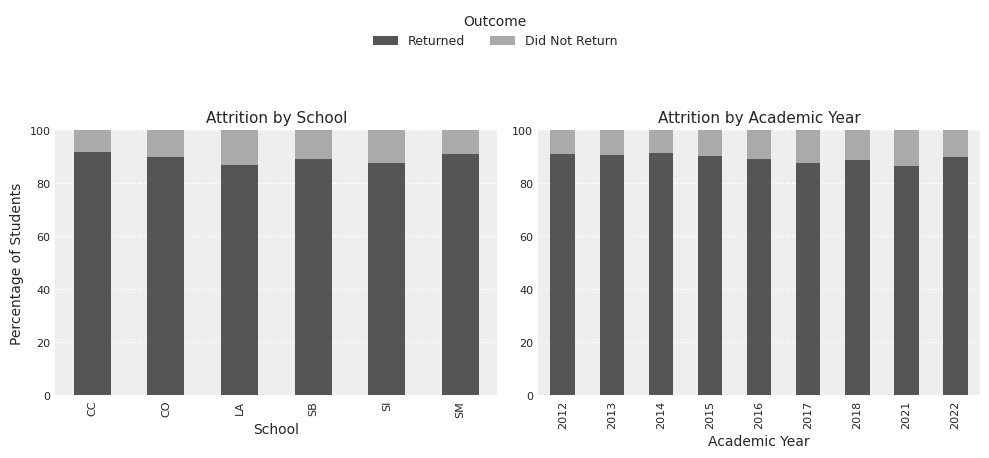

In [ ]:
plot_attrition_by_school_and_year(dfr);


In [ ]:
dfr

,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,...,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference,AcademicYear
0,-1.948809,-0.568557,NO,-0.375860,0.0,F,0.0,-0.317999,0.0,1.0,...,0.387906,0.0,0.0,0.0,-0.209702,-0.992060,0.0,0,-1.609850,2012
1,0.140622,-0.149352,NO,-0.375860,0.0,F,0.0,-0.320925,0.0,1.0,...,0.618590,0.0,0.0,0.0,-0.209702,-1.180679,0.0,0,0.682927,2012
2,0.140622,-0.213934,NO,-0.375860,0.0,F,0.0,-0.256555,0.0,1.0,...,0.138294,0.0,0.0,0.0,-0.209702,0.180600,0.0,1,-0.037660,2012
3,0.140622,0.330476,NO,-0.375860,0.0,M,0.0,-0.004927,0.0,1.0,...,-1.366272,0.0,0.0,0.0,-0.209702,-1.126227,0.0,0,-1.129458,2012
4,0.140622,-0.191674,NO,-0.375860,0.0,M,0.0,-0.296055,0.0,1.0,...,0.174824,0.0,0.0,0.0,-0.209702,-0.255009,1.0,0,0.748435,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13382,0.140622,-0.568557,YES,4.442645,0.0,M,1.0,0.002388,1.0,1.0,...,-2.982515,1.0,0.0,0.0,-0.209702,0.012890,0.0,0,1.338007,2022
13383,0.140622,-0.568557,NO,-0.375860,1.0,M,0.0,-0.385295,0.0,0.0,...,-0.503606,0.0,0.0,0.0,-0.209702,-1.997446,0.0,0,2.124102,2022
13384,0.140622,-0.568557,YES,3.478832,0.0,F,1.0,-0.364814,0.0,1.0,...,0.347040,0.0,0.0,0.0,-0.209702,0.906760,0.0,0,1.643710,2022
13385,0.140622,0.325164,NO,-0.375860,0.0,F,0.0,-0.350184,0.0,1.0,...,-2.016633,1.0,0.0,0.0,-0.209702,-1.997446,0.0,0,1.840234,2022


In [ ]:
#dfr.info()

In [ ]:
pd.set_option('display.max_columns', None)
dfr.head()

,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,HSRankPercent,HSGPA,NumAPCourses,NumHonorsCourses,NumIBHCourses,NumIBSCourses,applicantTypeCode,WaitListYN,isMeritScholarship,UnmetNeed,hasLoans,initialHousingAssignment,initialHousingRelocationCount,SchoolCode,MAJOR,isDivisionI,isLSP,isHonorsProgram,isCampusWorkStudy,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference,AcademicYear
0,-1.948809,-0.568557,NO,-0.37586,0.0,F,0.0,-0.317999,0.0,1.0,0,0.159753,-0.593937,-1.009906,-0.144538,-0.159865,RD,0.0,0.0,-0.224222,0.0,LE,0.052428,CO,FAS,0.0,0.0,0.0,0.0,0.387906,0.0,0.0,0.0,-0.209702,-0.992060,0.0,0,-1.609850,2012
1,0.140622,-0.149352,NO,-0.37586,0.0,F,0.0,-0.320925,0.0,1.0,0,0.586790,-0.202176,-0.419563,-0.144538,-0.159865,RD,0.0,0.0,0.598879,1.0,LE,0.052428,CO,FAS,0.0,0.0,0.0,0.0,0.618590,0.0,0.0,0.0,-0.209702,-1.180679,0.0,0,0.682927,2012
2,0.140622,-0.213934,NO,-0.37586,0.0,F,0.0,-0.256555,0.0,1.0,0,0.373271,-0.202176,-0.813125,-0.144538,-0.159865,RD,0.0,0.0,0.514757,1.0,CH,0.052428,SM,BAD,0.0,0.0,0.0,1.0,0.138294,0.0,0.0,0.0,-0.209702,0.180600,0.0,1,-0.037660,2012
3,0.140622,0.330476,NO,-0.37586,0.0,M,0.0,-0.004927,0.0,1.0,0,-2.188950,-0.202176,-0.222782,-0.144538,-0.159865,RD,0.0,1.0,-0.402447,0.0,CH,0.052428,SM,BAD,0.0,1.0,0.0,0.0,-1.366272,0.0,0.0,0.0,-0.209702,-1.126227,0.0,0,-1.129458,2012
4,0.140622,-0.191674,NO,-0.37586,0.0,M,0.0,-0.296055,0.0,1.0,0,-0.053766,-0.593937,-0.616344,-0.144538,-0.159865,RD,1.0,0.0,0.361484,0.0,SH,0.052428,CC,CMSC,0.0,0.0,0.0,0.0,0.174824,0.0,0.0,0.0,-0.209702,-0.255009,1.0,0,0.748435,2012


In [ ]:
dfr.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,10921.0,-2.243340e-15,1.000046,-4.038240,0.140622,0.140622,0.140622,10.587777
EFC,10921.0,-3.122979e-17,1.000046,-0.568557,-0.563007,-0.259285,0.141590,13.519988
pell_amount,10921.0,4.424220e-17,1.000046,-0.375860,-0.375860,-0.375860,-0.375860,4.442645
distanceFromHome,10921.0,3.643475e-17,1.000046,-0.385295,-0.312148,-0.285814,-0.217055,7.488337
HSRankPercent,10921.0,1.373501e-03,0.037037,0.000000,0.000000,0.000000,0.000000,1.000000
HSGPA,10921.0,3.466506e-15,1.000046,-19.056906,-0.694321,-0.053766,0.586790,4.216603
NumAPCourses,10921.0,-1.145092e-16,1.000046,-0.985698,-0.985698,-0.202176,0.581346,8.808324
NumHonorsCourses,10921.0,-5.465213e-17,1.000046,-1.009906,-0.813125,-0.222782,0.564342,4.499964
NumIBHCourses,10921.0,-1.040993e-17,1.000046,-0.144538,-0.144538,-0.144538,-0.144538,21.534464
NumIBSCourses,10921.0,1.561489e-17,1.000046,-0.159865,-0.159865,-0.159865,-0.159865,14.880886


In [ ]:
dfr[list(predictors1)]

NameError: name 'predictors1' is not defined

In [ ]:
#plot_correlation_heatmap(encode_binary_data_for_correlation(dfr))
encode_binary_data_for_correlation(dfr).corr()

,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,HSRankPercent,HSGPA,NumAPCourses,NumHonorsCourses,NumIBHCourses,NumIBSCourses,WaitListYN,isMeritScholarship,UnmetNeed,hasLoans,initialHousingRelocationCount,isDivisionI,isLSP,isHonorsProgram,isCampusWorkStudy,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference
AGE,1.000000,-0.019695,-0.024971,-0.012003,0.036481,0.108782,-0.024826,0.028599,-0.000932,-0.168011,0.000049,-0.064214,-0.090519,-0.058615,0.006845,0.008314,-0.014639,-0.039486,-0.093407,-0.091199,-0.006868,0.063477,0.074312,-0.029637,-0.052219,-0.054430,0.031884,0.016180,0.011295,0.046617,-0.033787,-0.029897,0.025309,-0.109549
EFC,-0.019695,1.000000,-0.227094,-0.210076,-0.110210,-0.001560,-0.092596,-0.017120,-0.061273,0.089128,-0.008459,0.042814,-0.008632,0.016638,-0.011490,-0.017371,-0.013962,0.039352,-0.328852,-0.111268,0.043928,-0.027180,0.032290,-0.002361,-0.159740,0.038509,-0.013252,0.041438,0.032327,0.008883,0.017878,0.026406,-0.018012,-0.029994
pellEligable,-0.024971,-0.227094,1.000000,0.894133,0.266302,0.000645,0.262497,0.065928,0.254609,0.007248,-0.001748,-0.031029,0.018843,-0.043362,0.006270,-0.001662,-0.020471,-0.032207,0.462389,0.218912,-0.101049,0.021591,-0.044817,-0.009987,0.238332,-0.091482,0.042562,-0.039106,-0.045302,0.016963,0.007232,-0.058090,0.020599,0.101331
pell_amount,-0.012003,-0.210076,0.894133,1.000000,0.273935,0.000210,0.287758,0.054220,0.355311,-0.002758,-0.004872,-0.035765,0.007859,-0.051672,0.012408,0.000751,-0.012475,-0.030680,0.398658,0.194791,-0.085757,0.013032,-0.040044,-0.013090,0.231728,-0.080640,0.037262,-0.036981,-0.041559,0.042434,0.007405,-0.056804,-0.003395,0.097818
studentOfColor,0.036481,-0.110210,0.266302,0.273935,1.000000,0.024700,0.130563,0.134363,0.208294,-0.222640,-0.006745,-0.081365,-0.016181,-0.074644,0.074720,0.068004,-0.005194,-0.047204,0.026094,0.038865,-0.069143,0.022093,-0.041942,-0.001887,0.093615,-0.104582,0.067565,-0.033727,-0.029575,0.038933,-0.017370,-0.068556,0.027814,0.090995
gender,0.108782,-0.001560,0.000645,0.000210,0.024700,1.000000,-0.035905,-0.052087,0.019305,-0.026843,-0.021001,-0.231067,-0.116195,-0.072579,-0.006563,0.000477,-0.001768,-0.105658,-0.006412,-0.015395,0.018365,0.111117,0.079525,-0.076680,-0.058590,-0.234404,0.107802,0.028369,0.016419,0.023233,-0.027387,-0.161938,0.006351,0.017106
isFirstGeneration,-0.024826,-0.092596,0.262497,0.287758,0.130563,-0.035905,1.000000,0.021268,0.150141,-0.038332,0.001170,0.015587,-0.039223,-0.049953,0.031634,0.031108,0.023613,0.008973,0.173512,0.106921,-0.053936,-0.033660,-0.040767,0.007077,0.103716,-0.034765,0.024994,-0.035690,-0.032908,0.039038,0.029621,-0.010320,0.024569,0.081424
distanceFromHome,0.028599,-0.017120,0.065928,0.054220,0.134363,-0.052087,0.021268,1.000000,-0.026451,0.003744,0.029350,0.030485,0.044392,-0.068185,0.043216,0.027334,-0.046930,0.002522,-0.011198,0.017028,-0.028084,0.078881,-0.025490,0.006048,0.029662,-0.010573,0.004628,-0.025221,-0.021091,0.000072,0.002055,-0.013031,0.042760,0.020707
isHEOP,-0.000932,-0.061273,0.254609,0.355311,0.208294,0.019305,0.150141,-0.026451,1.000000,-0.044266,-0.004007,-0.114192,-0.032256,-0.075362,-0.012130,-0.015287,-0.011909,-0.125064,0.012727,0.061970,0.019238,-0.043082,-0.025211,-0.033654,0.184892,-0.052417,0.007312,-0.034994,-0.029859,0.064013,-0.040715,-0.053402,-0.023190,0.043507
USCitizen,-0.168011,0.089128,0.007248,-0.002758,-0.222640,-0.026843,-0.038332,0.003744,-0.044266,1.000000,-0.008754,0.048437,0.060161,0.118314,-0.134677,-0.133306,0.023823,-0.011153,0.185012,0.150084,-0.004465,-0.008152,0.021881,0.007625,0.034513,0.029997,-0.028742,0.037721,0.033760,0.014587,0.040577,0.012533,-0.012452,-0.047071


**High Correlation Between Predictors (Multicollinearity)**

Multicollinearity can inflate variance in model estimates, making it harder to interpret coefficients. The following pairs show strong correlations (abs(r)>0.7, indicating a risk of redundancy:

- NumIBHCourses vs. NumIBSCourses (~0.83)
  - These are highly correlated, likely measuring similar academic preparation.
  - Action: Consider keeping only one of them.

- pellEligable vs. pell_amount (~0.89)
  - Pell eligibility is strongly related to Pell amounts.
  - Action: Keep only pell_amount since it carries more granular financial aid information.

- GPA_EffectiveEndOfAcademicYear vs. HSGPA (~0.49)
  - Somewhat correlated but conceptually different (high school GPA vs. college GPA).
  - Action: Keep both unless Variance Inflation Factor (VIF) suggests otherwise.

- isMeritScholarship vs. UnmetNeed (~0.50)
  - Financial need and merit-based aid are somewhat related.
  - Action: Consider testing models with and without isMeritScholarship.

- isAcademicProbation vs. GPA_EffectiveEndOfAcademicYear (~0.55)
  - Academic probation is likely based on GPA, making it somewhat redundant.
  - Action: Keep GPA_EffectiveEndOfAcademicYear and drop isAcademicProbation if needed.

**Low-Predictive Features**

Some variables have low correlations with the response variable (didNotReturnNextFallIR), meaning they may not contribute much to the model:

- HSRankPercent (~0.09)
- isLSP (~-0.07)
- DepositDaysDifference (~0.01)
  -  Action: Consider removing these if their Bayesian posterior intervals strongly overlap zero.

**Grouping and Interaction Effects**

Since you are using hierarchical logistic regression, you might interact key variables:

- SchoolCode & AcademicYear: Already included as hierarchical groups.
- EFC & UnmetNeed: Consider an interaction EFC * UnmetNeed since they both measure financial constraints.
 -  Action: Test interaction terms where relevant.

In [ ]:
vif_results = check_multicollinearity(encode_binary_data_for_correlation(dfr))
print(vif_results)

                          Variable        VIF
0                        Intercept  48.579269
1                              AGE   1.063284
2                              EFC   1.177892
3                      pell_amount   1.394746
4                   studentOfColor   1.201586
5                isFirstGeneration   1.120752
6                 distanceFromHome   1.044542
7                        USCitizen   1.198897
8                            HSGPA   1.727981
9                     NumAPCourses   1.397206
10                NumHonorsCourses   1.358650
11                   NumIBHCourses   2.356719
12                   NumIBSCourses   2.361337
13                      WaitListYN   1.114850
14              isMeritScholarship   1.661905
15                       UnmetNeed   1.826172
16                        hasLoans   1.355272
17   initialHousingRelocationCount   1.050972
18                     isDivisionI   1.130192
19                           isLSP   1.187230
20                 isHonorsProgram

Interpreting the Variance Inflation Factor (VIF) Results

Your VIF results look quite good overall, except for one major issue:

Most predictors have a VIF < 5, meaning multicollinearity is not a major concern.

The intercept has a very high VIF (~49), which suggests strong collinearity with other predictors.

A few predictors have VIF between 2.5 - 3.0, which may warrant attention.

In [ ]:
dfr['gender'].value_counts()

,count
gender,
F,6421
M,4500


In [ ]:
dfr

,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,...,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference,AcademicYear
0,0.140622,-0.032925,NO,-0.375860,0.0,M,0.0,-0.307759,0.0,1.0,...,0.364787,0.0,0.0,0.0,-0.209702,0.180600,1.0,0,0.399060,2016
1,0.140622,0.840284,NO,-0.375860,0.0,M,0.0,-0.315074,0.0,1.0,...,-0.293128,0.0,0.0,0.0,-0.209702,1.051818,0.0,0,0.377224,2012
2,0.140622,2.103873,NO,-0.375860,1.0,M,0.0,-0.016630,0.0,1.0,...,-3.599403,1.0,0.0,0.0,-0.209702,1.390722,0.0,0,-0.212347,2021
3,0.140622,0.005565,NO,-0.375860,0.0,M,0.0,-0.278500,0.0,1.0,...,0.814313,0.0,0.0,0.0,-0.209702,0.052531,0.0,0,0.355388,2018
4,0.140622,-0.568557,NO,-0.375860,0.0,F,0.0,-0.298981,0.0,1.0,...,1.210094,0.0,0.0,0.0,-0.209702,-1.180679,1.0,0,0.617420,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8728,0.140622,-0.568557,YES,2.780012,0.0,M,0.0,-0.225833,0.0,1.0,...,-0.196432,0.0,1.0,0.0,-0.209702,-1.126227,0.0,0,0.617420,2013
8729,0.140622,-0.543395,YES,1.801663,0.0,M,0.0,-0.304833,0.0,1.0,...,-1.479519,1.0,1.0,0.0,-0.209702,-1.180679,0.0,0,-2.046569,2013
8730,0.140622,-0.483561,NO,-0.375860,0.0,M,0.0,-0.301907,0.0,1.0,...,-1.747461,0.0,0.0,0.0,-0.209702,-0.545560,0.0,0,0.595584,2021
8731,-1.948809,-0.118977,NO,-0.375860,0.0,M,1.0,-0.348722,0.0,1.0,...,0.113023,0.0,0.0,0.0,-0.209702,-0.091656,0.0,0,0.355388,2015


-----------------------
# Bayesian hierarchical Logistic regression

In [ ]:
# List of predictors

predictors = (
    "EFC",
    "pell_amount",
    "studentOfColor",
    "gender",
    "isFirstGeneration",
    "distanceFromHome",
    #"isHEOP",
    #"USCitizen",
    "HSGPA",
    #"NumAPCourses",
    #"NumHonorsCourses",
    "WaitListYN",
    "UnmetNeed",
    "hasLoans",
    #"isDivisionI",
    "isCampusWorkStudy",
    "GPA_EffectiveEndOfAcademicYear"
)

predictors = (
              #"AcademicYear"
              #"SchoolCode",
              #"MAJOR",
              #"AGE",
              "EFC",
              #"pellEligable",
              "pell_amount",
              "studentOfColor",
              "gender",
              "isFirstGeneration",
              "distanceFromHome",
              #"isHEOP",
              "USCitizen",
              #"HSRankPercent",
              "HSGPA",
              "NumAPCourses",
              #"NumHonorsCourses",
              #"NumIBHCourses",
              #"NumIBSCourses",
              #"applicantTypeCode",
              "WaitListYN",
              #"isMeritScholarship",
              "UnmetNeed",
              "hasLoans",
              #"initialHousingAssignment",
              #"initialHousingRelocationCount",
              "isDivisionI",
              #"isLSP",
              #"isHonorsProgram",
              "isCampusWorkStudy",
              #"isAcademicProbation",
              #"isSelfDevelopment",
              #"isCareerPlanning",
              "tutoringClassCount",
              #"percentCreditsFullTimeFall",
              "ISDEANSLIST",
              #"DepositDaysDifference",
              "GPA_EffectiveEndOfAcademicYear",
              )

predictors = (
              "GPA_EffectiveEndOfAcademicYear",
              "ISDEANSLIST",
              "tutoringClassCount",
              "HSGPA",
              "NumAPCourses",
              "USCitizen",
              "gender",
              "studentOfColor",
              "isFirstGeneration",
              "isDivisionI",
              "isCampusWorkStudy",
              "WaitListYN",
              "distanceFromHome",
              "EFC",
              "UnmetNeed",
              "hasLoans",
              "pell_amount"
              )


# Create the formula string
#dependent_variable = "didNotReturnNextFallIR"
#predictors_string = " + ".join(predictors)
#predictors_string =predictors_string + " + " + "C(applicantTypeCode, levels=['EA', 'RD', 'EDI', 'EDII'])"
#predictors_string =predictors_string + " + applicantTypeCode

#formula = f"{dependent_variable} ~ {predictors_string}"
#formula



# Create the formula string
predictors_string = " + ".join(predictors)
dependent_variable = "didNotReturnNextFallIR"
group = "AcademicYear"
#group = "SchoolCode"
#group="applicantTypeCode"
predictors_string = " + ".join(predictors)

# Only Intercepts
formula = f"{dependent_variable} ~ {predictors_string} + (1 | SchoolCode)  + (1 | AcademicYear)"
formula

'didNotReturnNextFallIR ~ GPA_EffectiveEndOfAcademicYear + ISDEANSLIST + tutoringClassCount + HSGPA + NumAPCourses + USCitizen + gender + studentOfColor + isFirstGeneration + isDivisionI + isCampusWorkStudy + WaitListYN + distanceFromHome + EFC + UnmetNeed + hasLoans + pell_amount + (1 | SchoolCode)  + (1 | AcademicYear)'

## Intercept Prior in the Logit Model
**# 1. Why is the Intercept in the Logit Scal**e?
In logistic regression, the probability $p$ of an event occurring is modeled using t **logit functn**:

$$
\text{logit}(p) = \log \left( \frac{p}{1 - p} \right) = \beta_0 + \sum_{j=1}^{m} \betaj x_j
$$

where:
- $p$ is the probability of the outcome occurring (e.g., a student not returning next fall).
- $\beta_0$ (the intercept) reprents the **log-odds of attrition when all predicto are zero**.
- $\beta_j$ are the regression coefficients for predi

<br>ctors $x_j$.
Since the **logit function transforms probabilities into an unbounded real number scale**, the prior for the **intercept must also be defined .ls**e**.

---

## 2. Choosing a Normal Prior** for the Intercept

Given tat the dataset is *highly imbalanced** with an attrition rat ofapproximatel**10%**, we use a **Normal prr on he int{e}rcept**:

$$
\beta_0 \sm \m**al{N}(-2.2, 1)
$**$

### Why $\mu = -2.2$?

The **log-odds** are converted back to probability using te **sigmoid function**:

$$
p = \frc{1}

Since all numeric predictors are scaled using StandardScaler (mean=0, std=1), your priors should ideally:

Be centered around zero (✅ already done).
Have reasonable standard deviations that reflect expected effect sizes.
Prevent overly weak priors, which can cause sampling issues.

Key Issues in Current Prior Setup
Some priors have unnecessarily large standard deviations

Example: isHEOP ~ Normal(0, 22.097)
Since the predictors are z-scored, a standard deviation over 10+ is likely too large.
Weak priors allow extreme coefficient values, which may contribute to divergences.
Group-Level Effects (Random Effects) Lack Regularization

The priors for SchoolCode and AcademicYear (HalfNormal(15.68)) allow for very high variability, which may lead to unstable posteriors.
Binary Predictors (studentOfColor, gender, isFirstGeneration, etc.) Might Need Tighter Priors

If a binary predictor is scaled, a prior with too large a variance can make posterior inference unstable.
A Gaussian prior with a standard deviation between 2–3 is often better.
{1 + e^{-\text{logit}(p)}}
$$

assumes an overly wide distribution, implying a *
t attrition in a Bayesian hierarchical logistic regression framework.


In [ ]:
#dfr = dfr.drop(index=[7060])

       Formula: didNotReturnNextFallIR ~ GPA_EffectiveEndOfAcademicYear + ISDEANSLIST + tutoringClassCount + HSGPA + NumAPCourses + USCitizen + gender + studentOfColor + isFirstGeneration + isDivisionI + isCampusWorkStudy + WaitListYN + distanceFromHome + EFC + UnmetNeed + hasLoans + pell_amount + (1 | SchoolCode)  + (1 | AcademicYear)
        Family: bernoulli
          Link: p = logit
  Observations: 10921
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: -2.2, sigma: 1.0)
            GPA_EffectiveEndOfAcademicYear ~ StudentT(nu: 3.0, mu: 0.0, sigma: 2.5)
            ISDEANSLIST ~ StudentT(nu: 3.0, mu: 0.0, sigma: 2.5)
            tutoringClassCount ~ Normal(mu: 0.0, sigma: 1.0)
            HSGPA ~ StudentT(nu: 3.0, mu: 0.0, sigma: 2.5)
            NumAPCourses ~ Normal(mu: 0.0, sigma: 1.0)
            USCitizen ~ Normal(mu: 0.0, sigma: 1.0)
            gender ~ Normal(mu: 0.0, sigma: 1.0)
            studentOfColor ~ Normal(mu: 0.0, sigm

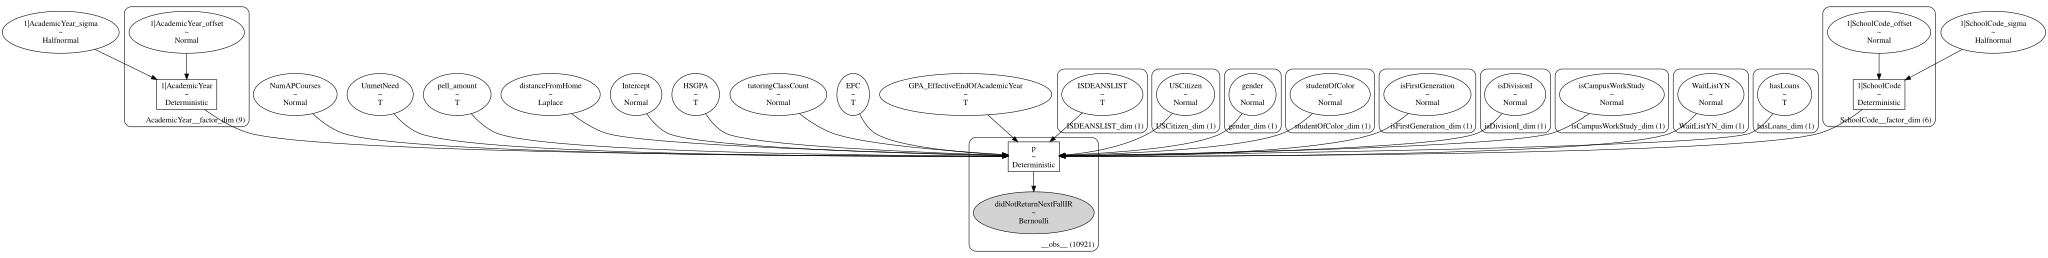

In [ ]:
#didNotReturnNextFallIR ~ EFC + pell_amount + studentOfColor +
#                         gender + isFirstGeneration + USCitizen +
#                         HSRankPercent + HSGPA + NumAPCourses +
#                         WaitListYN + UnmetNeed + hasLoans +
#                         isDivisionI + isCampusWorkStudy +
#                         tutoringClassCount + ISDEANSLIST +
#                         GPA_EffectiveEndOfAcademicYear + (1 | SchoolCode)  + (1 | AcademicYear)

priors = {
    "Intercept": bmb.Prior("Normal", mu=-2.2, sigma=1.0),

    # Continuous predictors (scaled)
    "EFC":bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "pell_amount": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "distanceFromHome": bmb.Prior("Laplace", mu=0, b=1),
    "HSGPA": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "UnmetNeed": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "GPA_EffectiveEndOfAcademicYear": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),

    # Binary predictors (scaled)
    #"studentOfColor": bmb.Prior("Normal", mu=0, sigma=3),
    #"gender": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"isFirstGeneration": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"USCitizen":  bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"applicantTypeCode": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"WaitListYN": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "hasLoans": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"isDivisionI": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    #"isCampusWorkStudy": bmb.Prior("Normal", mu=0, sigma=3),
    "ISDEANSLIST": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),

    # Group-Level Effects (Random Effects) - Now with Hyperpriors
    "1|SchoolCode": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5)),
    "1|AcademicYear": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5))
    }

# Build the Bambi model
model = bmb.Model(formula, data=dfr, family="bernoulli", priors=priors, noncentered=True)
print(model)

# Generate DAG visualization
model.build()
model.graph(figsize=(4,6), name="./bambi_dag")


In [ ]:
start_time = time.time()

fitted = model.fit(draws=4000,tune=1000,
                   chains=4,
                   cores=4,
                   #nuts_sampler="numpyro",
                   target_accept=0.99,
                  idata_kwargs={"log_likelihood": True})

end_time = time.time()

print(f"Time taken: {end_time - start_time} seconds")


Output()

Time taken: 313.3813829421997 seconds


In [ ]:
formula

'didNotReturnNextFallIR ~ GPA_EffectiveEndOfAcademicYear + ISDEANSLIST + tutoringClassCount + HSGPA + NumAPCourses + USCitizen + gender + studentOfColor + isFirstGeneration + isDivisionI + isCampusWorkStudy + WaitListYN + distanceFromHome + EFC + UnmetNeed + hasLoans + pell_amount + (1 | SchoolCode)  + (1 | AcademicYear)'

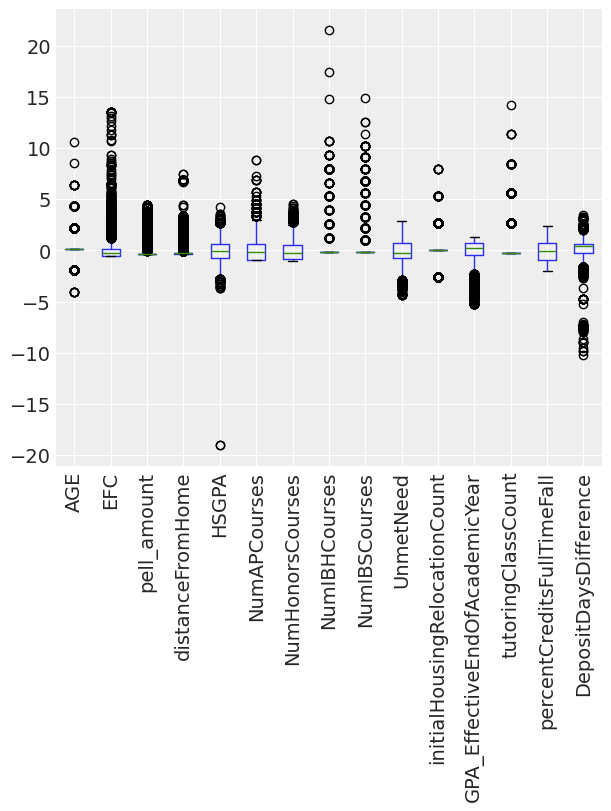

In [ ]:
float_columns = dfr.select_dtypes(include=['float64']).columns.tolist()
# Boxplot for a quick visual identification
dfr.boxplot(column=float_columns, figsize=(6, 8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
#fitted

In [ ]:
# Extract divergences from the trace
divergences = np.any(fitted.sample_stats.diverging, axis=-1)

# List out the indices of divergent transitions
divergent_indices = np.where(divergences)[0]

if divergent_indices.size > 0:
    print("Divergences found at the following indices:")
    print(divergent_indices)
else:
    print("No divergences found.")

No divergences found.


/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (35), generating only 20 plots
  warnings.warn(


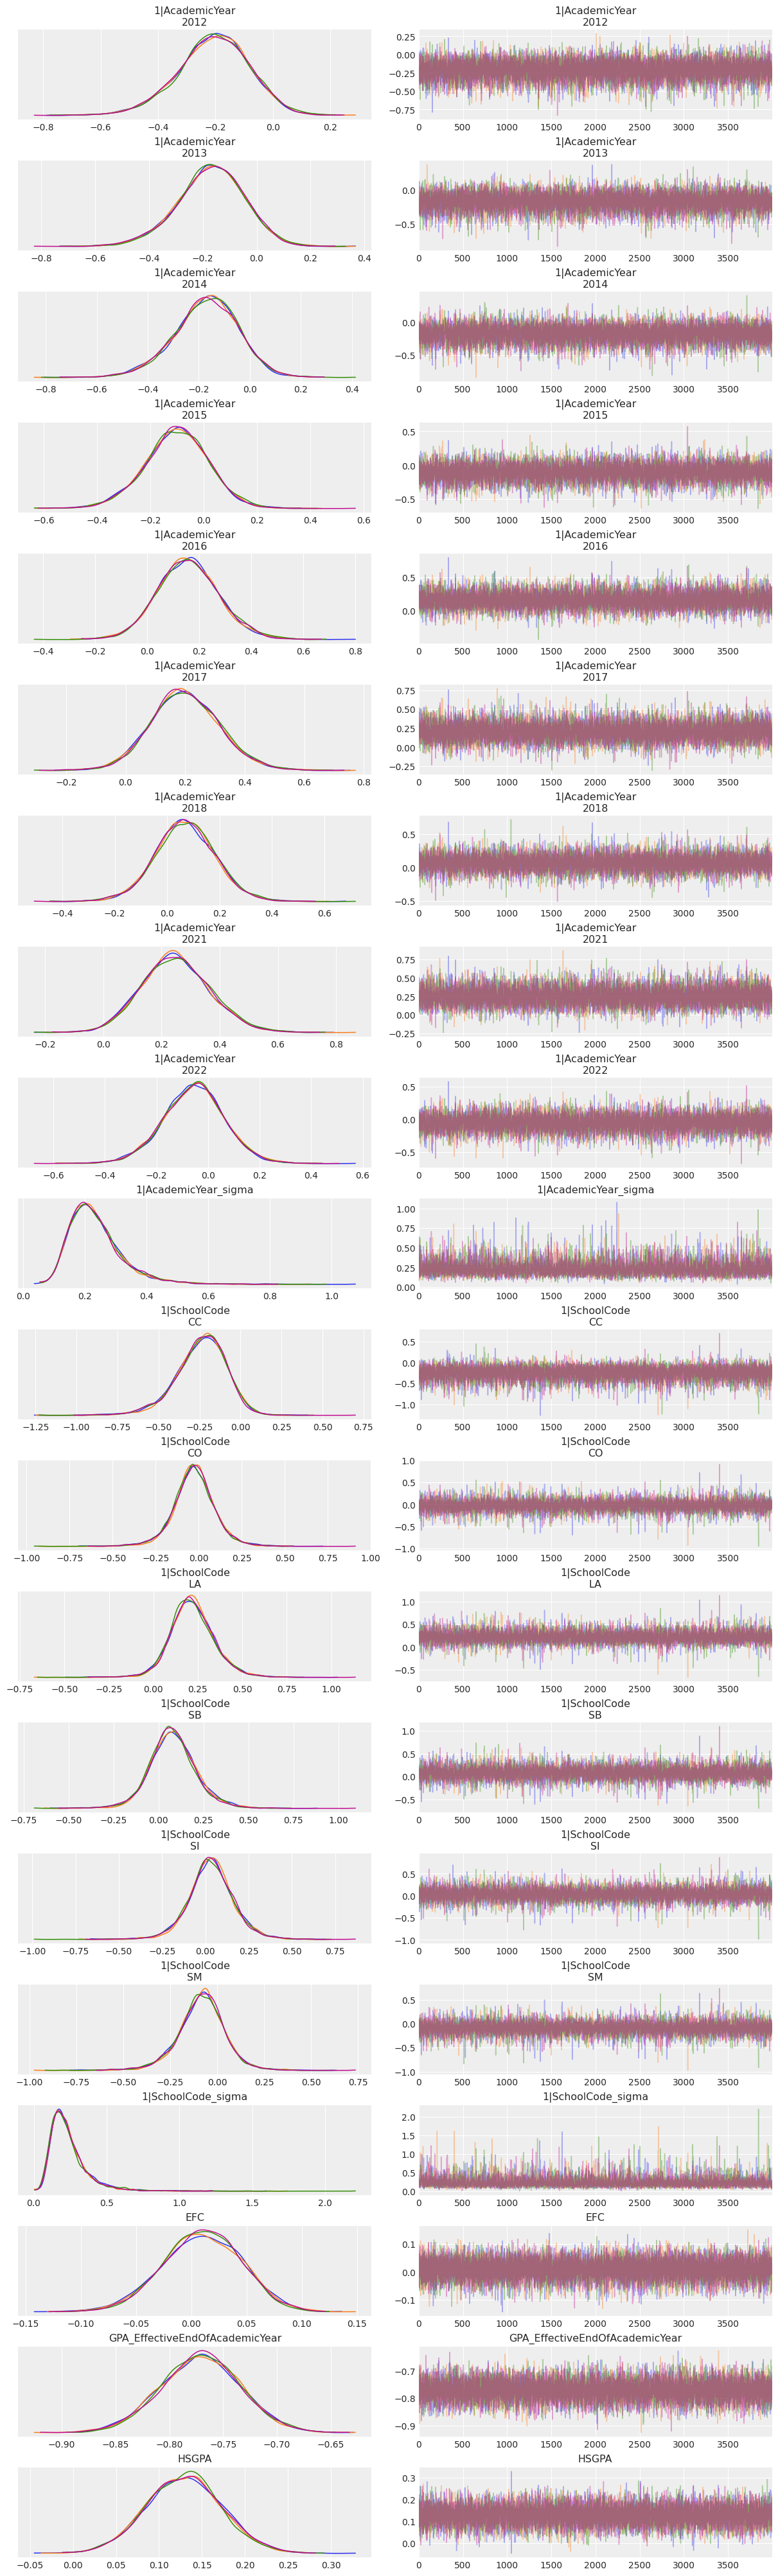

In [ ]:
#az.plot_trace(fitted, compact=False, backend_kwargs={"layout": "constrained"});
az.plot_trace(fitted, compact=False);


In [ ]:
#var_names=['Intercept','GPA_EffectiveEndOfAcademicYear']
var_names=filter_var_names(fitted, exclude_patterns=['^1\|', '^p$'])
# Calculate and add the % overlap with ROPE
#rope_min, rope_max=-0.15,0.15
rope_min, rope_max=-0.2,0.2
#updated_summary_df = add_rope_info(fitted_h, var_names, rope_min, rope_max,ropes=[(0.1,0.2),(0.5,0.6)])
updated_summary_df = add_rope_info(fitted, var_names, rope_min, rope_max, ropes=None)
updated_summary_df


<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-1877575153.py:2: SyntaxWarning: invalid escape sequence '\|'
  var_names=filter_var_names(fitted, exclude_patterns=['^1\|', '^p$'])


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,% posterior samples within ROPE,% 95% HDI within ROPE
Intercept,-2.325,0.268,-2.854,-1.817,0.003,0.002,9865.0,9627.0,1.0,0.00000,0.000000
EFC,0.010,0.035,-0.059,0.079,0.000,0.000,20022.0,10658.0,1.0,100.00000,100.000000
GPA_EffectiveEndOfAcademicYear,-0.770,0.037,-0.843,-0.699,0.000,0.000,18493.0,12419.0,1.0,0.00000,0.000000
HSGPA,0.128,0.043,0.047,0.216,0.000,0.000,19892.0,12549.0,1.0,94.88750,90.532544
ISDEANSLIST[1.0],0.568,0.096,0.384,0.760,0.001,0.001,19699.0,11773.0,1.0,0.00625,0.000000
NumAPCourses,-0.053,0.039,-0.130,0.022,0.000,0.000,21924.0,11898.0,1.0,100.00000,100.000000
USCitizen[1.0],-0.263,0.201,-0.652,0.135,0.001,0.002,19451.0,12060.0,1.0,36.46875,42.566709
UnmetNeed,0.368,0.044,0.281,0.452,0.000,0.000,15475.0,11752.0,1.0,0.00625,0.000000
WaitListYN[1.0],0.108,0.116,-0.129,0.324,0.001,0.001,21846.0,12296.0,1.0,78.02500,72.626932
distanceFromHome,0.123,0.028,0.068,0.179,0.000,0.000,23170.0,11375.0,1.0,99.76250,100.000000


In [ ]:
model

       Formula: didNotReturnNextFallIR ~ EFC + pell_amount + studentOfColor + gender + isFirstGeneration + distanceFromHome + isHEOP + USCitizen + HSGPA + NumAPCourses + NumHonorsCourses + WaitListYN + UnmetNeed + hasLoans + isDivisionI + isCampusWorkStudy + GPA_EffectiveEndOfAcademicYear + (1|SchoolCode) + (1|AcademicYear)
        Family: bernoulli
          Link: p = logit
  Observations: 8735
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 15.6806)
            EFC ~ Normal(mu: 0.0, sigma: 2.5427)
            pell_amount ~ Normal(mu: 0.0, sigma: 2.5235)
            studentOfColor ~ Normal(mu: 0.0, sigma: 7.5589)
            gender ~ Normal(mu: 0.0, sigma: 5.079)
            isFirstGeneration ~ Normal(mu: 0.0, sigma: 7.6562)
            distanceFromHome ~ Normal(mu: 0.0, sigma: 2.5112)
            isHEOP ~ Normal(mu: 0.0, sigma: 23.9792)
            USCitizen ~ Normal(mu: 0.0, sigma: 15.3249)
            HSGPA ~ Normal(mu: 0.

###The Model Might Be Underfitting on Certain Features
Check posterior distributions of coefficients. Are some important variables too weakly estimated (shrunk to zero)?

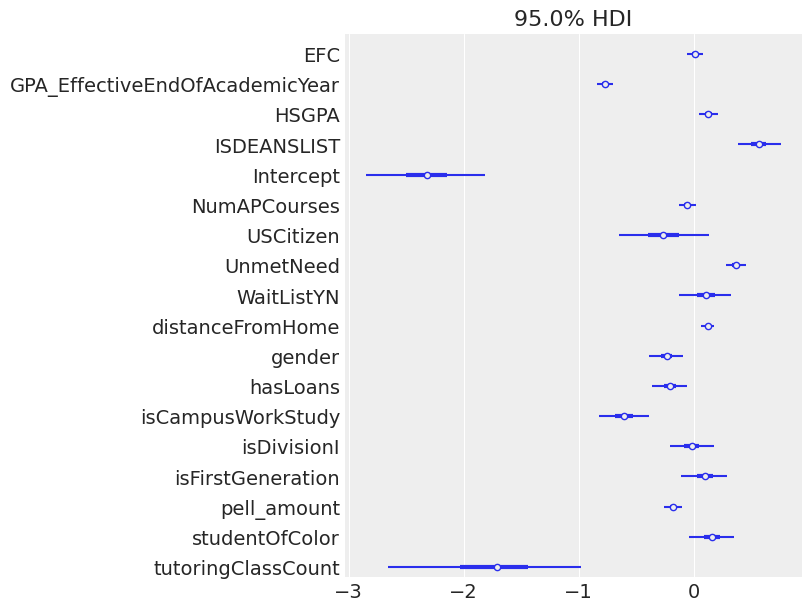

In [ ]:
az.plot_forest(fitted, var_names=var_names, combined=True,hdi_prob=0.95, figsize=(8, 6));



In [ ]:
#az.plot_posterior(fitted.posterior, var_names=["1|SchoolCode"],hdi_prob=0.95,figsize=(10, 6));



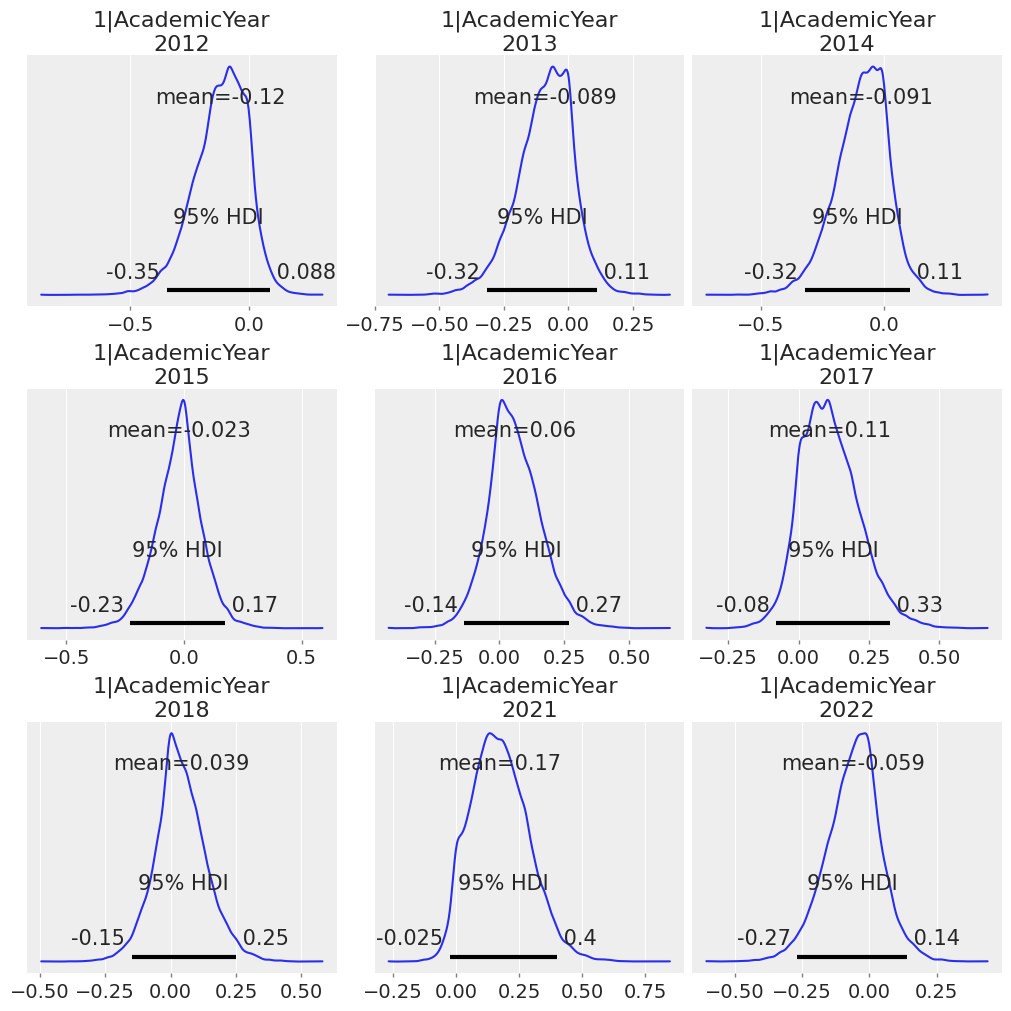

In [ ]:
az.plot_posterior(fitted.posterior, var_names=["1|AcademicYear"],hdi_prob=0.95,figsize=(10, 10));

In [ ]:
#fitted
#print(type(fitted.posterior_predictive))

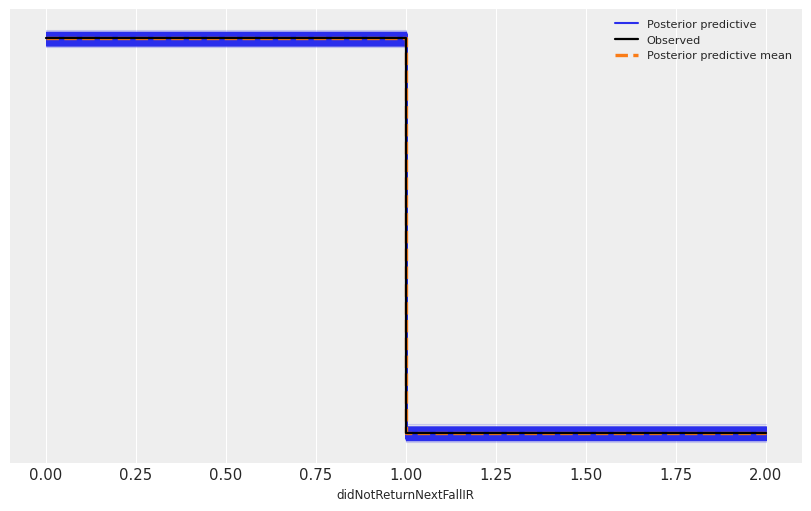

In [ ]:
# Step 1: Perform Posterior Predictive Checks on the Full Dataset
model.predict(fitted, kind="response")  # Generate posterior predictive samples

posterior_predictive_dict = {
    var: fitted.posterior_predictive[var].values for var in fitted.posterior_predictive.data_vars
}
observed_data_dict = {
    var: fitted.observed_data[var].values for var in fitted.observed_data.data_vars
}
idata_ppc = az.from_dict(
    posterior_predictive=posterior_predictive_dict,
    observed_data=observed_data_dict
)

# Plot Posterior Predictive Check
az.plot_ppc(idata_ppc, figsize=(8, 5))
plt.show()

### The PPC plot compares:

Observed data (black line) → The actual distribution of didNotReturnNextFallIR in your dataset.
Posterior predictive samples (blue shaded area) → The model’s simulated outcomes based on the posterior distribution.
Posterior predictive mean (orange dashed line) → The average prediction from the posterior distribution.

Key Observations
The model predicts almost the same proportions of 0s and 1s as the observed data

The black observed line and the blue predictive distribution overlap almost perfectly.
This suggests the model is fitting the data well, as the posterior predictive samples replicate the empirical distribution.
Sharp transition between 0 and 1

The model strongly separates retained students (0) and non-returning students (1).
This indicates that the Bayesian hierarchical model is making confident predictions rather than being uncertain.
If the model were underfitting, we would see a more spread-out predictive distribution.
Minimal posterior uncertainty (narrow bands)

The blue posterior predictive distribution is very tight, meaning that the model assigns high confidence to its predictions.
This can be a good sign, but it may also indicate overconfidence—especially if the dataset is imbalanced.


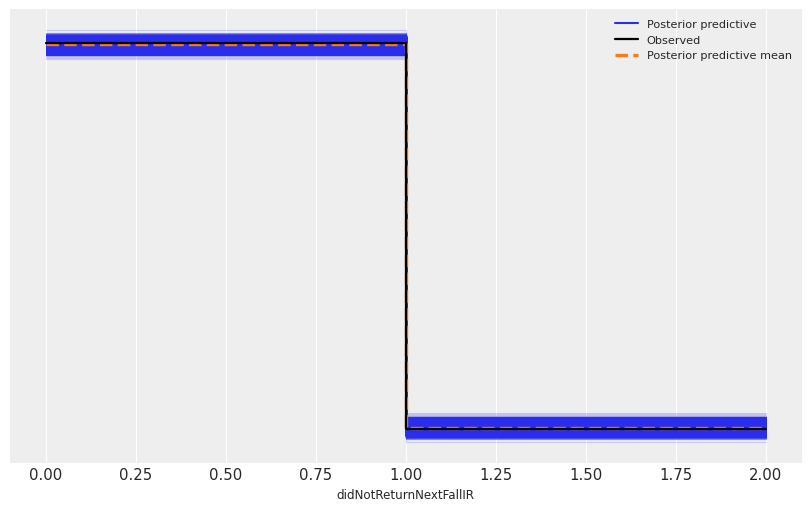

In [ ]:
# Step 1: Generate Posterior Predictive Samples on Test Data
model.predict(fitted, kind="response", data=dft, inplace=True)  # No assignment!

posterior_predictive_dict = {
    var: fitted.posterior_predictive[var].values for var in fitted.posterior_predictive.data_vars
}
observed_data_dict = {
    var: fitted.observed_data[var].values for var in fitted.observed_data.data_vars
}
idata_ppc = az.from_dict(
    posterior_predictive=posterior_predictive_dict,
    observed_data=observed_data_dict
)

# Plot Posterior Predictive Check
az.plot_ppc(idata_ppc, figsize=(8, 5))
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss, precision_recall_fscore_support, matthews_corrcoef

### Step 1: Generate Posterior Predictive Samples on Training Data
model.predict(fitted, kind="response", data=dfr, inplace=True)  # Predict on training set

ppc_train_array = fitted.posterior_predictive["didNotReturnNextFallIR"].values
y_pred_train_bayes = np.mean(ppc_train_array, axis=(0, 1))
y_pred_train_bayes_binary = (y_pred_train_bayes > 0.3).astype(int)
y_train = dfr["didNotReturnNextFallIR"]

### Step 2: Generate Posterior Predictive Samples on Test Data
model.predict(fitted, kind="response", data=dft, inplace=True)  # Predict on test set

ppc_test_array = fitted.posterior_predictive["didNotReturnNextFallIR"].values
y_pred_test_bayes = np.mean(ppc_test_array, axis=(0, 1))
y_pred_test_bayes_binary = (y_pred_test_bayes > 0.5).astype(int)
y_test = dft["didNotReturnNextFallIR"]

### Step 3: Compute Evaluation Metrics for Training & Test Data
def compute_metrics(y_true, y_pred_prob, y_pred_binary):
    auc = roc_auc_score(y_true, y_pred_prob)
    acc = accuracy_score(y_true, y_pred_binary)
    brier = brier_score_loss(y_true, y_pred_prob)
    mcc = matthews_corrcoef(y_true, y_pred_binary)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_binary, average="binary", beta=1)
    return auc, acc, brier,mcc, precision, recall, f1

# Compute metrics for training and test sets
train_metrics = compute_metrics(y_train, y_pred_train_bayes, y_pred_train_bayes_binary)
test_metrics = compute_metrics(y_test, y_pred_test_bayes, y_pred_test_bayes_binary)


df_comparison = pd.DataFrame({
    "Metric": ["AUC", "Accuracy", "Brier Score","mcc", "Precision", "Recall", "F1"],
    "Training Set": train_metrics,
    "Test Set": test_metrics
})

# Display results
print(df_comparison)


        Metric  Training Set  Test Set
0          AUC      0.714576  0.702987
1     Accuracy      0.897057  0.904022
2  Brier Score      0.082146  0.083114
3          mcc      0.298935  0.288126
4    Precision      0.530769  0.800000
5       Recall      0.224269  0.121212
6           F1      0.315308  0.210526


In [ ]:
brier_1

0.6814404711745691

In [ ]:
# Verify graphically the posterior and  in ROPE
#az.plot_posterior(fitted, var_names=predictors, hdi_prob=0.95, rope =[-0.18,0.18]);

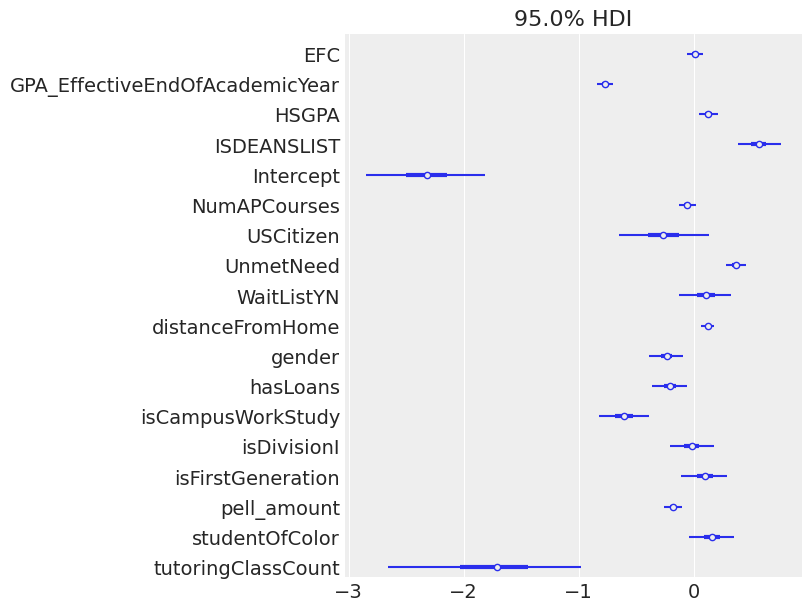

In [ ]:
az.plot_forest(fitted, var_names=var_names, combined=True,hdi_prob=0.95, figsize=(8, 6));

In [ ]:
# Extract the group-level (random) effects for SchoolCode
AcademicYear_effects = fitted.posterior["1|AcademicYear"].mean(dim=("chain", "draw"))

# Convert to pandas DataFrame for easier manipulation (if desired)
AcademicYear_effects_df = AcademicYear_effects.to_pandas()

# Summary using pandas describe
AcademicYear_summary = AcademicYear_effects_df.describe(percentiles=[0.025, 0.5, 0.975])
print(AcademicYear_summary)


count    9.000000
mean     0.000343
std      0.101577
min     -0.120982
2.5%    -0.114791
50%     -0.022865
97.5%    0.161661
max      0.174104
dtype: float64


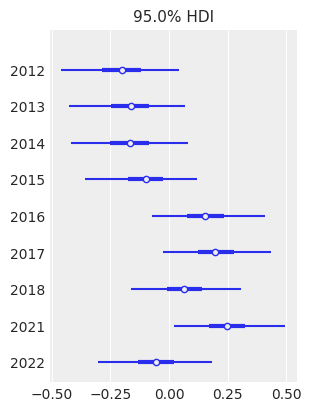

In [ ]:
plt.rcParams.update({
    'axes.labelsize': 8,  # Axis label font size
    'xtick.labelsize': 10,  # X-tick label font size
    'ytick.labelsize': 10,  # Y-tick label font size
    'legend.fontsize': 10,  # Legend font size
    'font.size': 10,  # General font size
    'axes.titlesize': 11  # Title font size
})

az.plot_forest(
    fitted,
    var_names=["1|AcademicYear"],  # Specify the group level you want to plot
    combined=True,
    hdi_prob=0.95,
    figsize=(3, 4)
)

# Get the current axes
ax = plt.gca()

# Get the current y-axis labels
y_labels = ax.get_yticklabels()

# Extract only the AcademicYear part
new_labels = [label.get_text().split('[')[-1][:-1] for label in y_labels]

# Set the new labels
ax.set_yticklabels(new_labels)

# Show the updated plot
plt.savefig("./random_effects_by_year.png")
plt.show()


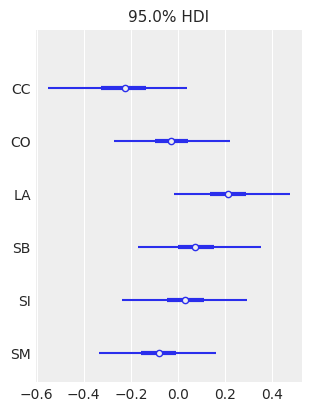

In [ ]:
plt.rcParams.update({
    'axes.labelsize': 8,  # Axis label font size
    'xtick.labelsize': 10,  # X-tick label font size
    'ytick.labelsize': 10,  # Y-tick label font size
    'legend.fontsize': 10,  # Legend font size
    'font.size': 10,  # General font size
    'axes.titlesize': 11  # Title font size
})

az.plot_forest(
    fitted,
    var_names=["1|SchoolCode"],  # Specify the group level you want to plot
    combined=True,
    hdi_prob=0.95,
    figsize=(3, 4)
)

# Get the current axes
ax = plt.gca()

# Get the current y-axis labels
y_labels = ax.get_yticklabels()

# Extract only the SchoolCode part
new_labels = [label.get_text().split('[')[-1][:-1] for label in y_labels]

# Set the new labels
ax.set_yticklabels(new_labels)

# Show the updated plot
plt.savefig("./random_effects_by_school.png")
plt.show()

### Model assessment
Before moving forward to inference, we can evaluate the quality of the model’s fit. We will take a look at two different ways of assessing how good is the model’s fit using its predictions.

#### Separation plot
There is a way of assessing the performance of a model with binary outcomes (such as logistic regression) in a visual way called separation plot. In a separation plot, the model’s predictions are averaged, ordered and represented as consecutive vertical lines. These vertical lines are colored according to the class indicated by their corresponding observed value, in this case light blue indicates class 0 and blue represents class 1. We can use the ArviZ’ implementation of the separation plot, but first we have to obtain the model’s predictions.

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      9772
           1       0.86      0.10      0.18      1154

    accuracy                           0.90     10926
   macro avg       0.88      0.55      0.57     10926
weighted avg       0.90      0.90      0.87     10926

[[9753   19]
 [1036  118]]


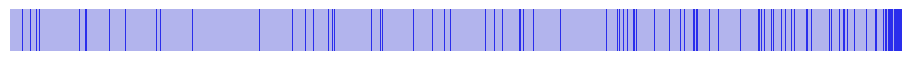

In [ ]:
model.predict(fitted, kind="pps")

from sklearn.metrics import classification_report, confusion_matrix
# Extract the posterior predictive samples
posterior_predictive = fitted.posterior_predictive['didNotReturnNextFallIR']

# Compute the mean prediction for each observation (average over chains and draws)
mean_predictions = posterior_predictive.mean(dim=("chain", "draw")).values

# Binarize the predictions based on a threshold (e.g., 0.5 for logistic regression)
predictions = (mean_predictions >= 0.5).astype(int)

# Map true labels to numerical format
true_labels = dfr['didNotReturnNextFallIR'].values

# Generate the classification report
report = classification_report(true_labels, predictions)
print(report)

print(confusion_matrix(true_labels, predictions))

#PLot separation
ax = az.plot_separation(fitted, y="didNotReturnNextFallIR", figsize=(9,0.5));


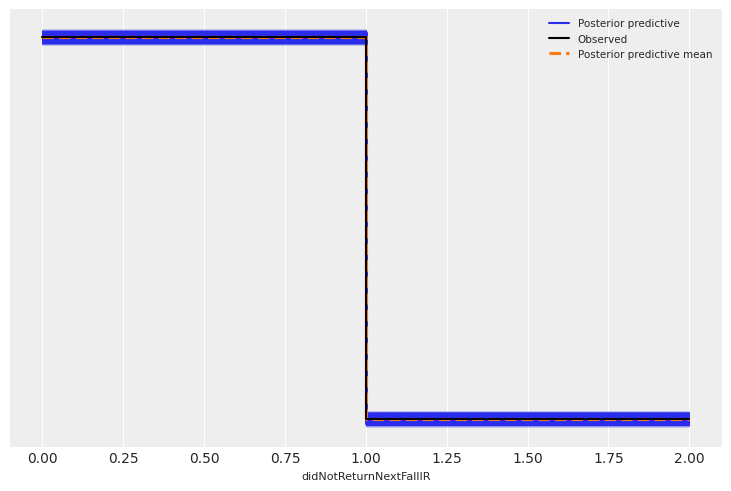

In [ ]:
#model.predict(fitted, kind="response")
az.plot_ppc(fitted);

In [ ]:
# Calculate WAIC and LOO on the test data
waic = az.waic(fitted)
loo = az.loo(fitted)

print(f"WAIC: {waic}")
print(f"LOO: {loo}")

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


WAIC: Computed from 16000 posterior samples and 10921 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -3239.46    66.63
p_waic       27.90        -
LOO: Computed from 16000 posterior samples and 10921 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3239.47    66.63
p_loo       27.91        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     10919  100.0%
   (0.70, 1]   (bad)          2    0.0%
   (1, Inf)   (very bad)     0    0.0%



/usr/local/lib/python3.12/dist-packages/arviz/plots/khatplot.py:167: FutureWarning: support for arrays will be deprecated, please use ELPDData.The reason for this, is that we need to know the numbers of drawssampled from the posterior
  warnings.warn(


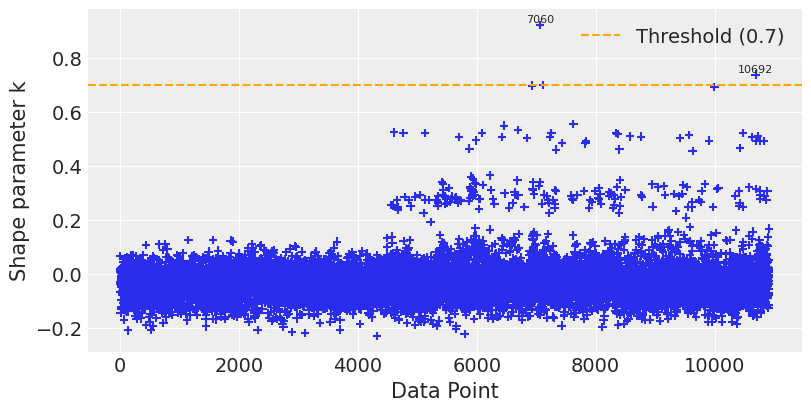

In [ ]:
# Step 1: Extract Pareto k values from LOO
pareto_k_values = loo.pareto_k.values.ravel()

# Step 2: Set threshold (recommended: 0.7)
threshold = 0.7

# Step 3: Identify influential observations
influential_indices = np.where(pareto_k_values >= threshold)[0]

# Step 4: Plot k-values
fig, ax = plt.subplots(figsize=(8, 4))
ax = az.plot_khat(pareto_k_values, ax=ax)

# Step 5: Add horizontal threshold line at k=0.7
ax.axhline(threshold, ls="--", color="orange", label=f"Threshold ({threshold})")

# Step 6: Annotate influential observations
for idx in influential_indices:
    y = pareto_k_values[idx]
    ax.text(idx, y + 0.01, str(idx), ha="center", va="baseline", fontsize=8)

# Step 7: Display plot
ax.legend()
plt.show()

# Step 8: Extract influential observations from dataframe
influential_observations = dfr.iloc[influential_indices]

In [ ]:
var_names

['EFC',
 'GPA_EffectiveEndOfAcademicYear',
 'HSGPA',
 'ISDEANSLIST',
 'Intercept',
 'NumAPCourses',
 'USCitizen',
 'UnmetNeed',
 'WaitListYN',
 'distanceFromHome',
 'gender',
 'hasLoans',
 'isCampusWorkStudy',
 'isDivisionI',
 'isFirstGeneration',
 'pell_amount',
 'studentOfColor',
 'tutoringClassCount']

In [ ]:
predictor_list=['EFC',
 'GPA_EffectiveEndOfAcademicYear',
 'HSGPA',
 'ISDEANSLIST',
 'NumAPCourses',
 'USCitizen',
 'UnmetNeed',
 'WaitListYN',
 'distanceFromHome',
 'gender',
 'hasLoans',
 'isCampusWorkStudy',
 'isDivisionI',
 'isFirstGeneration',
 'pell_amount',
 'studentOfColor',
 'tutoringClassCount']
# Extract Pareto k values from LOO
pareto_k_values = loo.pareto_k.values.ravel()

# Find indices where k >= 0.7 (bad influence)
influential_indices = np.where(pareto_k_values >= 0.7)[0]

# Display the indices of influential observations
print("Influential Observations:", influential_indices)

# Extract the actual data points from the dataframe
influential_observations = dfr.iloc[influential_indices][predictor_list]
display(influential_observations)


Influential Observations: [ 7060 10692]


,EFC,GPA_EffectiveEndOfAcademicYear,HSGPA,ISDEANSLIST,NumAPCourses,USCitizen,UnmetNeed,WaitListYN,distanceFromHome,gender,hasLoans,isCampusWorkStudy,isDivisionI,isFirstGeneration,pell_amount,studentOfColor,tutoringClassCount
7062,0.147860,0.685503,-0.694321,1.0,-0.985698,1.0,0.107217,0.0,-0.301907,F,0.0,0.0,1.0,0.0,-0.375860,0.0,14.230125
13158,-0.568557,-0.228820,-0.480803,0.0,-0.985698,1.0,1.634663,0.0,-0.331166,F,1.0,0.0,0.0,1.0,3.478832,1.0,11.342160


In [ ]:
df_filtered = df.drop(index=[957, 1537, 4024, 4789, 5979])

**or else**

We can also use ArviZ to compute LOO and find influential observations using the estimated  Kappa parameter value.

An observation is influential in the sense that if we refit the data by first removing that observation from the data set, the fitted result will be more different than if we do the same for a non influential observation. Clearly the level of influence of observations can vary continuously. An observation can be influential either because it is an outlier (a measurement error, a data entry error, etc) or because the model is not flexible enough to capture the observation. The approximations used to compute LOO are no longer reliable for
Kappa >0.7

/home/eitel/anaconda3/envs/bayes/lib/python3.12/site-packages/arviz/plots/khatplot.py:184: FutureWarning: support for DataArrays will be deprecated, please use ELPDData.The reason for this, is that we need to know the numbers of drawssampled from the posterior
  warnings.warn(


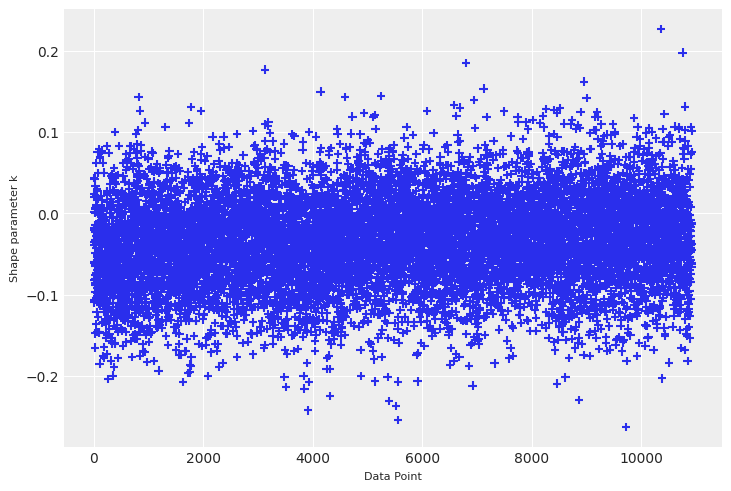

In [ ]:
# compute pointwise LOO
loo = az.loo(fitted, pointwise=True)

# plot kappa values
az.plot_khat(loo.pareto_k);

/home/eitel/anaconda3/envs/bayes/lib/python3.12/site-packages/arviz/plots/khatplot.py:167: FutureWarning: support for arrays will be deprecated, please use ELPDData.The reason for this, is that we need to know the numbers of drawssampled from the posterior
  warnings.warn(


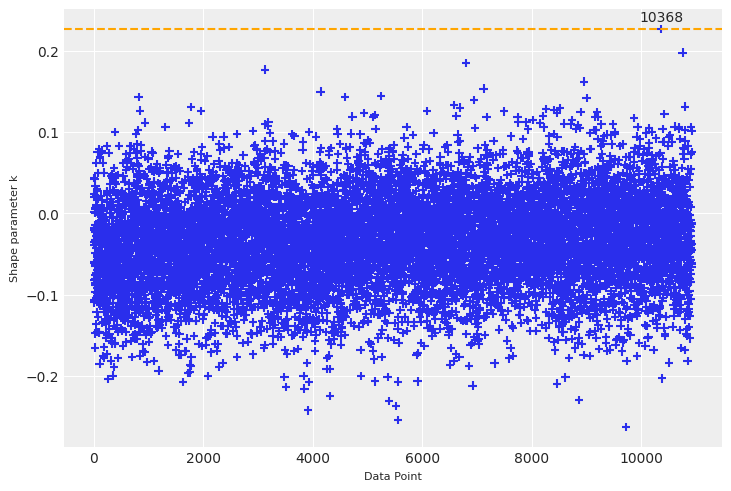

In [ ]:
ax = az.plot_khat(loo.pareto_k.values.ravel())
sorted_kappas = np.sort(loo.pareto_k.values.ravel())

# find observation where the kappa value exceeds the threshold
threshold = sorted_kappas[-1:]
ax.axhline(threshold, ls="--", color="orange")
influential_observations = dfr.reset_index()[loo.pareto_k.values >= threshold].index

for x in influential_observations:
    y = loo.pareto_k.values[x]
    ax.text(x, y + 0.01, str(x), ha="center", va="baseline")

In [ ]:
dfr.reset_index()[loo.pareto_k.values >= threshold]

,index,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,HSRankPercent,HSGPA,NumAPCourses,NumHonorsCourses,NumIBHCourses,NumIBSCourses,applicantTypeCode,WaitListYN,isMeritScholarship,UnmetNeed,hasLoans,initialHousingAssignment,initialHousingRelocationCount,SchoolCode,MAJOR,isDivisionI,isLSP,isHonorsProgram,isCampusWorkStudy,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference,AcademicYear
10368,12828,0.140589,-0.568445,NO,-0.376122,1.0,M,0.0,-0.385394,0.0,0.0,0,-19.05924,-0.986078,-1.010291,-0.144504,-0.159827,RD,0.0,1.0,-1.709844,0.0,CH,-2.585689,SM,BAD,0.0,0.0,0.0,0.0,-2.606526,1.0,0.0,0.0,-0.209652,-1.996844,0.0,0,-2.046712,2022


/home/eitel/anaconda3/envs/bayes/lib/python3.12/site-packages/arviz/plots/khatplot.py:184: FutureWarning: support for DataArrays will be deprecated, please use ELPDData.The reason for this, is that we need to know the numbers of drawssampled from the posterior
  warnings.warn(


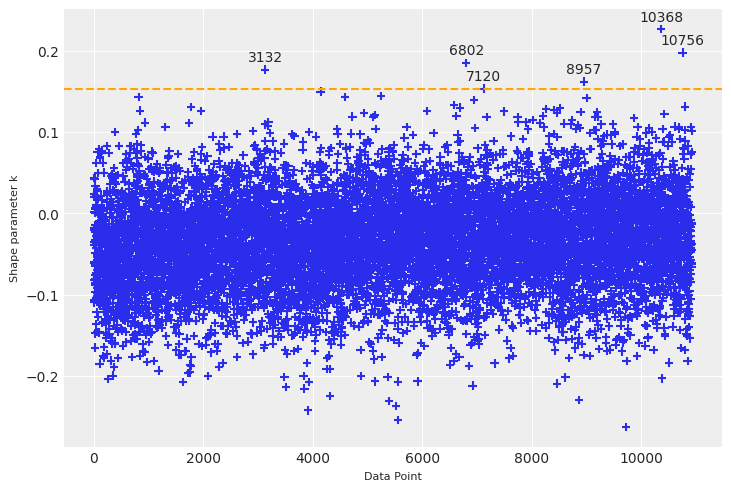

In [ ]:
ax = az.plot_khat(loo.pareto_k)

# find observation where the kappa value exceeds the threshold
threshold = sorted_kappas[-6:].min()
ax.axhline(threshold, ls="--", color="orange")
influential_observations = dfr.reset_index()[loo.pareto_k.values >= threshold].index

for x in influential_observations:
    y = loo.pareto_k.values[x]
    ax.text(x, y + 0.01, str(x), ha="center", va="baseline")

In [ ]:
dfr.reset_index()[loo.pareto_k.values>=threshold]

,index,AGE,EFC,pellEligable,pell_amount,studentOfColor,gender,isFirstGeneration,distanceFromHome,isHEOP,USCitizen,HSRankPercent,HSGPA,NumAPCourses,NumHonorsCourses,NumIBHCourses,NumIBSCourses,applicantTypeCode,WaitListYN,isMeritScholarship,UnmetNeed,hasLoans,initialHousingAssignment,initialHousingRelocationCount,SchoolCode,MAJOR,isDivisionI,isLSP,isHonorsProgram,isCampusWorkStudy,GPA_EffectiveEndOfAcademicYear,isAcademicProbation,isSelfDevelopment,isCareerPlanning,tutoringClassCount,percentCreditsFullTimeFall,ISDEANSLIST,didNotReturnNextFallIR,DepositDaysDifference,AcademicYear
3132,3134,-1.949311,-0.568445,YES,2.825481,1.0,M,0.0,-0.302015,1.0,1.0,0,-2.189369,0.972312,-0.419958,-0.144504,-0.159827,RD,0.0,0.0,0.140620,1.0,LE,0.052641,SI,BIOL,0.0,0.0,0.0,0.0,-1.835705,1.0,0.0,0.0,-0.209652,0.664419,0.0,1,0.661113,2014
6802,6804,0.140589,-0.168259,NO,-0.376122,0.0,F,0.0,-0.287387,0.0,1.0,0,-19.059240,-0.986078,-1.010291,-0.144504,-0.159827,RD,0.0,1.0,0.463189,1.0,MA,0.052641,CO,DGM,0.0,0.0,0.0,1.0,0.976515,0.0,0.0,0.0,-0.209652,0.295126,1.0,0,0.508252,2017
7120,7122,0.140589,-0.568445,YES,3.880949,0.0,M,1.0,-0.296164,1.0,1.0,0,-1.335199,-0.986078,-1.010291,-0.144504,-0.159827,RD,0.0,0.0,0.131710,0.0,MR,0.052641,SB,CRJU,0.0,0.0,0.0,1.0,-1.347776,0.0,0.0,0.0,-0.209652,0.012930,0.0,1,0.027831,2018
8957,11408,0.140589,13.477586,NO,-0.376122,0.0,M,0.0,-0.272759,0.0,1.0,0,0.373143,-0.594400,0.170375,-0.144504,-0.159827,EA,0.0,1.0,-1.115794,0.0,MA,0.052641,CC,CSI,0.0,0.0,0.0,0.0,0.221646,0.0,0.0,0.0,-0.209652,1.704798,0.0,0,-0.037681,2021
10368,12828,0.140589,-0.568445,NO,-0.376122,1.0,M,0.0,-0.385394,0.0,0.0,0,-19.059240,-0.986078,-1.010291,-0.144504,-0.159827,RD,0.0,1.0,-1.709844,0.0,CH,-2.585689,SM,BAD,0.0,0.0,0.0,0.0,-2.606526,1.0,0.0,0.0,-0.209652,-1.996844,0.0,0,-2.046712,2022
10756,13217,-1.949311,-0.568445,YES,4.439693,0.0,F,1.0,-0.294701,1.0,1.0,0,-0.053943,0.188956,-0.813513,-0.144504,-0.159827,EA,0.0,0.0,0.145076,1.0,MR,0.052641,SI,BIO,0.0,0.0,0.0,1.0,0.185729,0.0,0.0,0.0,-0.209652,2.115898,0.0,1,0.180692,2022


## With Cauchy priors

In [ ]:
# Specify the Cauchy prior correctly with 'alpha' (location) and 'beta' (scale)
priors_cauchy = {
    "Intercept": bmb.Prior("Cauchy", alpha=0, beta=2.5),
    "common": bmb.Prior("Cauchy", alpha=0, beta=2.5),  # Prior for all fixed effects
    "1|SchoolCode": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5)),
    "1|AcademicYear": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5))
}

# Create the model with specified priors
model_cauchy = bmb.Model(formula, dfr, family="bernoulli", priors=priors_cauchy)

print(model_cauchy)

       Formula: didNotReturnNextFallIR ~ GPA_EffectiveEndOfAcademicYear + ISDEANSLIST + tutoringClassCount + HSGPA + NumAPCourses + USCitizen + gender + studentOfColor + isFirstGeneration + isDivisionI + isCampusWorkStudy + WaitListYN + distanceFromHome + EFC + UnmetNeed + hasLoans + pell_amount + (1 | SchoolCode)  + (1 | AcademicYear)
        Family: bernoulli
          Link: p = logit
  Observations: 10921
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Cauchy(alpha: 0.0, beta: 2.5)
            GPA_EffectiveEndOfAcademicYear ~ Cauchy(alpha: 0.0, beta: 2.5)
            ISDEANSLIST ~ Cauchy(alpha: 0.0, beta: 2.5)
            tutoringClassCount ~ Cauchy(alpha: 0.0, beta: 2.5)
            HSGPA ~ Cauchy(alpha: 0.0, beta: 2.5)
            NumAPCourses ~ Cauchy(alpha: 0.0, beta: 2.5)
            USCitizen ~ Cauchy(alpha: 0.0, beta: 2.5)
            gender ~ Cauchy(alpha: 0.0, beta: 2.5)
            studentOfColor ~ Cauchy(alpha: 0.0, beta: 2.5)
        

In [ ]:
start_time = time.time()

fitted_cauchy = model_cauchy.fit(draws=4000,tune=1000,
                   chains=4,
                   cores=4,
                   #nuts_sampler="numpyro",
                   target_accept=0.99,
                  idata_kwargs={"log_likelihood": True})

end_time = time.time()

print(f"Time taken: {end_time - start_time} seconds")

Output()

Time taken: 929.3043539524078 seconds


In [ ]:
# Calculate WAIC and LOO on the test data
waic_cauchy = az.waic(fitted_cauchy)
loo_cauchy = az.loo(fitted_cauchy)

print(f"WAIC: {waic_cauchy}")
print(f"LOO: {loo_cauchy}")

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


WAIC: Computed from 16000 posterior samples and 10921 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -3239.17    66.68
p_waic       28.21        -
LOO: Computed from 16000 posterior samples and 10921 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3239.18    66.68
p_loo       28.22        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     10881   99.6%
   (0.70, 1]   (bad)         35    0.3%
   (1, Inf)   (very bad)     5    0.0%



##Let's check for interactions

In [ ]:
import bambi as bmb
import time

# Step 1: Interaction formula (focusing on significant predictors from your Table 3)
formula_interactions = """
didNotReturnNextFallIR ~
GPA_EffectiveEndOfAcademicYear * UnmetNeed +
GPA_EffectiveEndOfAcademicYear * gender +
UnmetNeed * isCampusWorkStudy +
GPA_EffectiveEndOfAcademicYear * tutoringClassCount +
ISDEANSLIST + HSGPA + pell_amount + hasLoans +
USCitizen + studentOfColor + isFirstGeneration + isDivisionI +
WaitListYN + distanceFromHome + EFC + NumAPCourses +
(1 | SchoolCode) + (1 | AcademicYear)
"""

# Step 2: Priors (your original priors + conservative priors for interactions)
priors_interactions = {
    "Intercept": bmb.Prior("Normal", mu=-2.2, sigma=1.0),

    # Main effects (keeping your original priors exactly)
    "GPA_EffectiveEndOfAcademicYear": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "UnmetNeed": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "ISDEANSLIST": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "tutoringClassCount": bmb.Prior("Normal", mu=0, sigma=1.0),
    "HSGPA": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "pell_amount": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "hasLoans": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "EFC": bmb.Prior("StudentT", nu=3, mu=0, sigma=2.5),
    "gender": bmb.Prior("Normal", mu=0, sigma=1.0),
    "isCampusWorkStudy": bmb.Prior("Normal", mu=0, sigma=1.0),
    "USCitizen": bmb.Prior("Normal", mu=0, sigma=1.0),
    "studentOfColor": bmb.Prior("Normal", mu=0, sigma=1.0),
    "isFirstGeneration": bmb.Prior("Normal", mu=0, sigma=1.0),
    "isDivisionI": bmb.Prior("Normal", mu=0, sigma=1.0),
    "WaitListYN": bmb.Prior("Normal", mu=0, sigma=1.0),
    "NumAPCourses": bmb.Prior("Normal", mu=0, sigma=1.0),
    "distanceFromHome": bmb.Prior("Laplace", mu=0, b=1),

    # NEW: Interaction terms (conservative priors)
    "GPA_EffectiveEndOfAcademicYear:UnmetNeed": bmb.Prior("Normal", mu=0, sigma=0.5),
    "GPA_EffectiveEndOfAcademicYear:gender": bmb.Prior("Normal", mu=0, sigma=0.5),
    "UnmetNeed:isCampusWorkStudy": bmb.Prior("Normal", mu=0, sigma=0.5),
    "GPA_EffectiveEndOfAcademicYear:tutoringClassCount": bmb.Prior("Normal", mu=0, sigma=0.5),

    # Group-Level Effects (same as your original)
    "1|SchoolCode": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5)),
    "1|AcademicYear": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2.5))
}

# Step 3: Build the interactions model
print("Building Interactions Model...")
model_interactions = bmb.Model(formula_interactions, data=dfr, family="bernoulli",
                              priors=priors_interactions, noncentered=True)
print(model_interactions)


Building Interactions Model...
       Formula: 
didNotReturnNextFallIR ~ 
GPA_EffectiveEndOfAcademicYear * UnmetNeed +
GPA_EffectiveEndOfAcademicYear * gender +
UnmetNeed * isCampusWorkStudy +
GPA_EffectiveEndOfAcademicYear * tutoringClassCount +
ISDEANSLIST + HSGPA + pell_amount + hasLoans + 
USCitizen + studentOfColor + isFirstGeneration + isDivisionI + 
WaitListYN + distanceFromHome + EFC + NumAPCourses +
(1 | SchoolCode) + (1 | AcademicYear)

        Family: bernoulli
          Link: p = logit
  Observations: 10920
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: -2.2, sigma: 1.0)
            GPA_EffectiveEndOfAcademicYear ~ StudentT(nu: 3.0, mu: 0.0, sigma: 2.5)
            UnmetNeed ~ StudentT(nu: 3.0, mu: 0.0, sigma: 2.5)
            GPA_EffectiveEndOfAcademicYear:UnmetNeed ~ Normal(mu: 0.0, sigma: 0.5)
            gender ~ Normal(mu: 0.0, sigma: 1.0)
            GPA_EffectiveEndOfAcademicYear:gender ~ Normal(mu: 0.0, sigma: 0.5)
  

In [ ]:
# Step 4: Fit using your exact approach
print("\nFitting Interactions Model...")
start_time = time.time()

fitted_interactions = model_interactions.fit(draws=4000,
                                           tune=1000,
                                           chains=4,
                                           cores=4,
                                           #nuts_sampler="numpyro",
                                           target_accept=0.99,
                                           idata_kwargs={"log_likelihood": True})

end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")


Fitting Interactions Model...


Output()

Time taken: 245.38646578788757 seconds


In [ ]:
#var_names=['Intercept','GPA_EffectiveEndOfAcademicYear']
var_names_i=filter_var_names(fitted_interactions, exclude_patterns=['^1\|', '^p$'])
# Calculate and add the % overlap with ROPE
#rope_min, rope_max=-0.15,0.15
rope_min, rope_max=-0.2,0.2
#updated_summary_df = add_rope_info(fitted_h, var_names, rope_min, rope_max,ropes=[(0.1,0.2),(0.5,0.6)])
i_summary_df = add_rope_info(fitted_interactions, var_names_i, rope_min, rope_max, ropes=None)
i_summary_df

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-1939630870.py:2: SyntaxWarning: invalid escape sequence '\|'
  var_names_i=filter_var_names(fitted_interactions, exclude_patterns=['^1\|', '^p$'])


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,% posterior samples within ROPE,% 95% HDI within ROPE
Intercept,-2.331,0.269,-2.855,-1.806,0.003,0.002,9624.0,10060.0,1.0,0.00000,0.000000
EFC,0.008,0.036,-0.063,0.077,0.000,0.000,20832.0,12589.0,1.0,100.00000,100.000000
GPA_EffectiveEndOfAcademicYear,-0.606,0.085,-0.775,-0.445,0.001,0.001,9104.0,10555.0,1.0,0.00000,0.000000
GPA_EffectiveEndOfAcademicYear:UnmetNeed,0.033,0.026,-0.020,0.084,0.000,0.000,17011.0,11796.0,1.0,100.00000,100.000000
GPA_EffectiveEndOfAcademicYear:gender[M],-0.219,0.058,-0.332,-0.104,0.000,0.000,18395.0,13471.0,1.0,37.17500,42.105263
GPA_EffectiveEndOfAcademicYear:tutoringClassCount,0.230,0.332,-0.395,0.887,0.003,0.002,9626.0,10736.0,1.0,39.08125,31.201248
HSGPA,0.127,0.044,0.043,0.213,0.000,0.000,19689.0,12956.0,1.0,95.28125,92.352941
ISDEANSLIST[1.0],0.511,0.097,0.326,0.707,0.001,0.001,19288.0,12928.0,1.0,0.04375,0.000000
NumAPCourses,-0.055,0.039,-0.131,0.022,0.000,0.000,22877.0,12427.0,1.0,99.98125,100.000000
USCitizen[1.0],-0.255,0.202,-0.645,0.145,0.002,0.002,17875.0,12493.0,1.0,37.49375,43.670886


In [ ]:
# Step 5: Generate comprehensive summary using your approach
print("\n" + "="*80)
print("INTERACTIONS MODEL COMPREHENSIVE SUMMARY")
print("="*80)

# Use your filtering and ROPE analysis approach
var_names_interactions = filter_var_names(fitted_interactions,
                                        exclude_patterns=['^1\|', '^p$'],
                                        include_intercept=True)

# Set ROPE for interactions (more conservative than main effects)
rope_min, rope_max = -0.1, 0.1  # Smaller ROPE for interactions

# Generate summary with ROPE analysis
interactions_summary_df = add_rope_info(fitted_interactions,
                                      var_names_interactions,
                                      rope_min, rope_max,
                                      ropes=None)

print("Full Summary:")
interactions_summary_df

<>:8: SyntaxWarning: invalid escape sequence '\|'
<>:8: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-3422626415.py:8: SyntaxWarning: invalid escape sequence '\|'
  exclude_patterns=['^1\|', '^p$'],



INTERACTIONS MODEL COMPREHENSIVE SUMMARY
Full Summary:


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,% posterior samples within ROPE,% 95% HDI within ROPE
Intercept,-2.331,0.269,-2.855,-1.806,0.003,0.002,9624.0,10060.0,1.0,0.00000,0.000000
EFC,0.008,0.036,-0.063,0.077,0.000,0.000,20832.0,12589.0,1.0,99.39375,100.000000
GPA_EffectiveEndOfAcademicYear,-0.606,0.085,-0.775,-0.445,0.001,0.001,9104.0,10555.0,1.0,0.00000,0.000000
GPA_EffectiveEndOfAcademicYear:UnmetNeed,0.033,0.026,-0.020,0.084,0.000,0.000,17011.0,11796.0,1.0,99.45000,100.000000
GPA_EffectiveEndOfAcademicYear:gender[M],-0.219,0.058,-0.332,-0.104,0.000,0.000,18395.0,13471.0,1.0,2.12500,0.000000
GPA_EffectiveEndOfAcademicYear:tutoringClassCount,0.230,0.332,-0.395,0.887,0.003,0.002,9626.0,10736.0,1.0,20.46250,15.600624
HSGPA,0.127,0.044,0.043,0.213,0.000,0.000,19689.0,12956.0,1.0,26.84375,33.529412
ISDEANSLIST[1.0],0.511,0.097,0.326,0.707,0.001,0.001,19288.0,12928.0,1.0,0.00000,0.000000
NumAPCourses,-0.055,0.039,-0.131,0.022,0.000,0.000,22877.0,12427.0,1.0,87.72500,79.738562
USCitizen[1.0],-0.255,0.202,-0.645,0.145,0.002,0.002,17875.0,12493.0,1.0,17.86250,25.316456


In [ ]:
# Step 6: Focus specifically on interaction terms
print("\n" + "="*80)
print("INTERACTION TERMS ANALYSIS")
print("="*80)

# Extract only interaction terms (those with ':' in the name)
interaction_terms = [var for var in interactions_summary_df.index if ':' in var]

if interaction_terms:
    interaction_summary = interactions_summary_df.loc[interaction_terms]
    print("Interaction Terms Summary:")

    # Check what columns are actually available
    print("Available columns:", list(interaction_summary.columns))

    # Use the correct column names from your dataframe
    display_columns = ['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', '%  95% HDI within ROPE']  # Note the double space
    print(interaction_summary[display_columns])

    print(f"\nDetailed Analysis of {len(interaction_terms)} Interaction Terms:")
    print("-" * 60)

    for term in interaction_terms:
        row = interaction_summary.loc[term]
        mean_val = row['mean']
        hdi_low = row['hdi_2.5%']
        hdi_high = row['hdi_97.5%']
        rope_overlap = row['%  95% HDI within ROPE']  # Note the double space

        # Determine significance
        statistically_significant = not (hdi_low <= 0 <= hdi_high)
        practically_significant = rope_overlap < 50  # Less than 50% in ROPE

        print(f"\n{term}:")
        print(f"  Coefficient: {mean_val:.4f}")
        print(f"  95% HDI: [{hdi_low:.4f}, {hdi_high:.4f}]")
        print(f"  % HDI in ROPE: {rope_overlap:.1f}%")
        print(f"  Statistically significant: {statistically_significant}")
        print(f"  Practically significant: {practically_significant}")

        # Interpretation based on your actual results
        if term == "GPA_EffectiveEndOfAcademicYear:gender[M]":
            if statistically_significant and practically_significant:
                print(f"  🔍 FINDING: Higher GPA provides stronger protection for male students")
                print(f"    - Male students with higher GPA have {abs(mean_val):.3f} lower log-odds of attrition")
                print(f"    - Suggests gender-specific academic resilience patterns")

        elif term == "UnmetNeed:isCampusWorkStudy[1.0]":
            if statistically_significant and practically_significant:
                print(f"  🔍 FINDING: Work-study students are MORE vulnerable to financial stress")
                print(f"    - Each unit increase in unmet need increases attrition risk by {mean_val:.3f} log-odds for work-study students")
                print(f"    - Counterintuitive: work-study may indicate higher baseline financial stress")

        elif term == "GPA_EffectiveEndOfAcademicYear:UnmetNeed":
            if not statistically_significant:
                print(f"  ⚪ No evidence that GPA buffers financial stress effects")
                print(f"    - Academic performance doesn't protect against financial pressures")

        elif term == "GPA_EffectiveEndOfAcademicYear:tutoringClassCount":
            if not statistically_significant:
                print(f"  ⚪ Tutoring effectiveness doesn't vary by GPA level")
                print(f"    - Tutoring appears equally beneficial across performance levels")

        else:
            # Generic interpretation for any other interactions
            if statistically_significant and practically_significant:
                direction = "increases" if mean_val > 0 else "decreases"
                print(f"  🔍 FINDING: This interaction significantly {direction} attrition risk")
            elif not statistically_significant:
                print(f"  ⚪ No evidence of interaction effect")
            else:
                print(f"  ⚠️ Statistically significant but may not be practically meaningful")

else:
    print("No interaction terms found in the model.")


INTERACTION TERMS ANALYSIS
Interaction Terms Summary:
Available columns: ['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'mcse_mean', 'mcse_sd', 'ess_bulk', 'ess_tail', 'r_hat', '% posterior samples within ROPE', '%  95% HDI within ROPE']
                                                    mean     sd  hdi_2.5%  \
GPA_EffectiveEndOfAcademicYear:UnmetNeed           0.033  0.026    -0.020   
GPA_EffectiveEndOfAcademicYear:gender[M]          -0.219  0.058    -0.332   
GPA_EffectiveEndOfAcademicYear:tutoringClassCount  0.230  0.332    -0.395   
UnmetNeed:isCampusWorkStudy[1.0]                   0.439  0.178     0.091   

                                                   hdi_97.5%  \
GPA_EffectiveEndOfAcademicYear:UnmetNeed               0.084   
GPA_EffectiveEndOfAcademicYear:gender[M]              -0.104   
GPA_EffectiveEndOfAcademicYear:tutoringClassCount      0.887   
UnmetNeed:isCampusWorkStudy[1.0]                       0.787   

                                                   %  95% HDI

In [ ]:
# Step 7: Model comparison with baseline
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Calculate WAIC and LOO on the test data
waic_interactions = az.waic(fitted_interactions)
loo_interactions = az.loo(fitted_interactions)

# Compute WAIC and LOO for interactions model
#waic_interactions = model_interactions.compute_log_likelihood(fitted_interactions).waic
#loo_interactions = model_interactions.compute_log_likelihood(fitted_interactions).loo

print(f"Interactions Model WAIC: {waic_interactions}")
print(f"Interactions Model LOO: {loo_interactions}")

# Compare with your baseline (baseline is model without interactions)

#print(f"\nWAIC improvement over baseline: {waic - waic_interactions:.2f}")
#print(f"LOO improvement over baseline: {loo - loo_interactions:.2f}")


MODEL COMPARISON


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Interactions Model WAIC: Computed from 16000 posterior samples and 10920 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -3230.48    66.67
p_waic       30.69        -
Interactions Model LOO: Computed from 16000 posterior samples and 10920 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3230.49    66.67
p_loo       30.70        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     10917  100.0%
   (0.70, 1]   (bad)          3    0.0%
   (1, Inf)   (very bad)     0    0.0%



In [ ]:
# Step 7b: Formal model comparison (run this if you have both models)
if 'fitted' in locals():  # Check if you have your baseline model
    # Calculate baseline performance
    waic_baseline = waic
    loo_baseline = loo

    # Extract values for comparison
    baseline_waic = waic_baseline.elpd_waic
    interactions_waic = waic_interactions.elpd_waic
    baseline_loo = loo_baseline.elpd_loo
    interactions_loo = loo_interactions.elpd_loo

    # Calculate differences (positive = interactions model is better)
    waic_diff = interactions_waic - baseline_waic
    loo_diff = interactions_loo - baseline_loo

    print(f"\n" + "="*60)
    print("FORMAL MODEL COMPARISON")
    print("="*60)
    print(f"Baseline Model:")
    print(f"  ELPD_WAIC: {baseline_waic:.2f}")
    print(f"  ELPD_LOO: {baseline_loo:.2f}")
    print(f"")
    print(f"Interactions Model:")
    print(f"  ELPD_WAIC: {interactions_waic:.2f}")
    print(f"  ELPD_LOO: {interactions_loo:.2f}")
    print(f"")
    print(f"Improvement (Interactions - Baseline):")
    print(f"  WAIC: {waic_diff:.2f}")
    print(f"  LOO: {loo_diff:.2f}")

    # Interpretation
    if waic_diff > 0 and loo_diff > 0:
        print(f"✅ Interactions model shows better predictive performance on both metrics")
    elif waic_diff > 0 or loo_diff > 0:
        print(f"⚠️ Mixed results - one metric favors interactions model")
    else:
        print(f"❌ Baseline model shows better predictive performance")

    # Use ArviZ's formal comparison
    model_dict = {'baseline': fitted, 'interactions': fitted_interactions}
    comparison_df = az.compare(model_dict)
    print(f"\nFormal Statistical Comparison:")
    print(comparison_df)

else:
    print("Baseline model ('fitted') not found. Please run baseline model first for comparison.")


FORMAL MODEL COMPARISON
Baseline Model:
  ELPD_WAIC: -3239.25
  ELPD_LOO: -3239.26

Interactions Model:
  ELPD_WAIC: -3230.48
  ELPD_LOO: -3230.49

Improvement (Interactions - Baseline):
  WAIC: 8.77
  LOO: 8.76
✅ Interactions model shows better predictive performance on both metrics


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



Formal Statistical Comparison:
              rank     elpd_loo      p_loo  elpd_diff    weight         se  \
interactions     0 -3230.494825  30.703265   0.000000  0.922088  66.668345   
baseline         1 -3239.258989  27.899421   8.764164  0.077912  66.650256   

                  dse  warning scale  
interactions  0.00000     True   log  
baseline      4.56218     True   log  


In [ ]:
type(loo)

arviz.stats.stats_utils.ELPDData